# URL Multiclass — Ablation Logistic Regression avec cross-validation group-aware

Ce notebook cherche à **isoler l'origine du gain** observé entre la baseline V1 et la Candidate V2.

La Candidate V2 avait amélioré le split 80/20 de référence :

- macro-F1 : `0.7283 → 0.7732` ;
- balanced accuracy : `0.7440 → 0.7841` ;
- F1 phishing : `0.6147 → 0.7215` ;
- recall phishing : environ `0.486 → 0.625`.

Mais trois changements avaient été introduits simultanément :

1. suppression du downsampling et utilisation du train complet ;
2. `class_weight="balanced"` ;
3. remplacement de cinq features par leur version `log1p`.

Cette expérience doit répondre à la question :

> **quelle composante apporte réellement le gain, et la Logistic Regression a-t-elle encore une marge suffisante avant de tester une autre famille de modèles ?**

---

## Configurations comparées

Toutes les configurations utilisent **le même train de référence** et exactement les **mêmes folds group-aware**.

| Code | Features | Train | Class weight |
|---|---|---|---|
| A | brutes | complet | aucun |
| B | brutes | complet | `balanced` |
| C | `log1p` | complet | aucun |
| D | `log1p` | complet | `balanced` |

Cette matrice permet d'isoler :

- `B - A` → effet du class weighting sur features brutes ;
- `C - A` → effet de `log1p` sans weighting ;
- `D - B` → effet marginal de `log1p` lorsque les classes sont pondérées ;
- `D - C` → effet marginal du weighting avec les features transformées ;
- `D - A` → effet combiné.

---

## Principe d'évaluation

Le split externe 80/20 de la baseline est reconstruit pour figer la population de référence.

**Le test externe n'est pas utilisé pour sélectionner les configurations dans ce notebook.**

Toutes les comparaisons A/B/C/D sont réalisées uniquement dans le train externe via :

`StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)`

Chaque `group_key` appartient à un seul fold.

Nous calculons :

- métriques validation par fold ;
- moyenne et écart-type ;
- métriques par classe ;
- prédictions OOF (*out-of-fold*) ;
- matrices de confusion OOF ;
- deltas appariés entre configurations.

Les prédictions OOF sont particulièrement utiles : chaque observation du train externe est prédite par un modèle qui n'a jamais vu son `group_key`.

## 0. Environnement, sécurité et reproductibilité

Le notebook :

- charge `.env` avec `python-dotenv` ;
- ne révèle jamais la valeur du DSN ;
- accède à PostgreSQL en transaction `READ ONLY` ;
- ne charge ni URL brute, ni hostname, ni hash, ni métadonnées source ;
- ne persiste aucun split ou modèle ;
- utilise le seed fixe `42`.

Toute dérive du snapshot ou de la quarantaine par rapport aux expériences précédentes bloque l'exécution.

In [1]:
from __future__ import annotations

import os
import platform
import sys
import time
import warnings
from contextlib import contextmanager
from pathlib import Path

from dotenv import load_dotenv


def find_project_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in (
        current,
        *current.parents,
    ):
        if (
            (candidate / "application").is_dir()
            and (candidate / "infrastructure").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Impossible de retrouver la racine du projet. "
        "Lancer Jupyter depuis le dépôt."
    )


PROJECT_ROOT = find_project_root()

load_dotenv(
    dotenv_path=PROJECT_ROOT / ".env",
    override=False,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

if not os.environ.get(
    "INGESTION_DATABASE_URL"
):
    raise RuntimeError(
        "INGESTION_DATABASE_URL n'est pas définie."
    )

print("Project root: détecté")
print(
    "INGESTION_DATABASE_URL: "
    "définie (valeur masquée)"
)

Project root: détecté
INGESTION_DATABASE_URL: définie (valeur masquée)


In [2]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import sklearn
    import sqlalchemy

    from IPython.display import display
    from sqlalchemy import text

    from sklearn.exceptions import (
        ConvergenceWarning,
    )
    from sklearn.linear_model import (
        LogisticRegression,
    )
    from sklearn.metrics import (
        accuracy_score,
        average_precision_score,
        balanced_accuracy_score,
        classification_report,
        cohen_kappa_score,
        confusion_matrix,
        ConfusionMatrixDisplay,
        f1_score,
        jaccard_score,
        log_loss,
        matthews_corrcoef,
        precision_score,
        recall_score,
        roc_auc_score,
        top_k_accuracy_score,
    )
    from sklearn.model_selection import (
        StratifiedGroupKFold,
    )
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import (
        StandardScaler,
        label_binarize,
    )

    from infrastructure.persistence.sqlalchemy.engine import (
        create_ingestion_engine,
    )

except ImportError as exc:
    raise RuntimeError(
        "Une dépendance EDA/ML est manquante. "
        "Installer explicitement les dépendances "
        "du projet avant d'exécuter ce notebook."
    ) from exc


pd.set_option(
    "display.max_columns",
    120,
)
pd.set_option(
    "display.max_rows",
    120,
)
pd.set_option(
    "display.width",
    200,
)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("SQLAlchemy:", sqlalchemy.__version__)

Python: 3.12.6
pandas: 2.2.3
numpy: 2.2.6
matplotlib: 3.10.0
scikit-learn: 1.6.1
SQLAlchemy: 2.0.51


In [3]:
RANDOM_SEED = 42

DATASET_NAME = (
    "url_multiclass_pool"
)
DATASET_VERSION = (
    "2026-08-12-v1"
)
EXPECTED_FEATURE_SET_VERSION = (
    "2.0.0"
)

LABEL_ORDER = [
    "benign",
    "malware",
    "phishing",
]

EXPECTED_LABELS = set(
    LABEL_ORDER
)

RAW_FEATURE_COLUMNS = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
    "path_length_special_char_ratio_product",
    "path_segment_count_special_char_ratio_product",
]

LOG1P_FEATURES = [
    "url_length",
    "dot_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
]

LOG1P_COLUMN_MAP = {
    feature: f"log1p_{feature}"
    for feature
    in LOG1P_FEATURES
}

LOG_FEATURE_COLUMNS = [
    LOG1P_COLUMN_MAP.get(
        feature,
        feature,
    )
    for feature
    in RAW_FEATURE_COLUMNS
]

EXPECTED_POOL_ROWS = 155_818
EXPECTED_QUARANTINED_ROWS = 12_126
EXPECTED_SPLIT_READY_ROWS = 143_692

EXPECTED_POST_QUARANTINE_COUNTS = {
    "benign": 58_433,
    "phishing": 56_668,
    "malware": 28_591,
}

EXPECTED_EXTERNAL_TRAIN_COUNTS = {
    "benign": 46_599,
    "phishing": 43_475,
    "malware": 24_057,
}

EXPECTED_EXTERNAL_TEST_COUNTS = {
    "benign": 11_834,
    "phishing": 13_193,
    "malware": 4_534,
}

EXTERNAL_SPLIT_N_SPLITS = 5
INTERNAL_CV_N_SPLITS = 5

HISTORICAL_BASELINE = {
    "test_macro_f1": 0.7283,
    "test_balanced_accuracy": 0.7440,
    "test_f1_phishing": 0.6147,
    "test_recall_phishing": 0.486,
}

HISTORICAL_CANDIDATE_V2 = {
    "test_macro_f1": 0.7732,
    "test_balanced_accuracy": 0.7841,
    "test_f1_phishing": 0.7215,
    "test_recall_phishing": 0.6247,
}

print("Seed:", RANDOM_SEED)
print(
    "Configurations d'ablation: A, B, C, D"
)

Seed: 42
Configurations d'ablation: A, B, C, D


## 1. Charger et vérifier le snapshot

Nous reconstruisons le même dataset que dans les notebooks précédents.

Ce notebook ne doit pas servir à comparer des modèles si le snapshot a changé entre-temps : cela mélangerait variation de modèle et variation de données.

In [4]:
engine = create_ingestion_engine()


@contextmanager
def read_connection():
    with engine.connect() as connection:
        with connection.begin():
            connection.execute(
                text(
                    "SET TRANSACTION READ ONLY"
                )
            )
            yield connection


with read_connection() as connection:
    read_only_state = (
        connection.execute(
            text(
                """
                SELECT current_setting(
                    'transaction_read_only'
                )
                """
            )
        )
        .scalar_one()
    )

if read_only_state != "on":
    raise RuntimeError(
        "La transaction PostgreSQL "
        "n'est pas read-only."
    )

print(
    "Transaction PostgreSQL read-only confirmée."
)

Transaction PostgreSQL read-only confirmée.


In [5]:
snapshot_query = text(
    """
    SELECT
        id::text AS dataset_id,
        name,
        version,
        status,
        projection_version,
        feature_set_version,
        class_targets,
        label_mapping,
        created_at,
        frozen_at
    FROM ml.dataset_snapshot
    WHERE name = :dataset_name
      AND version = :dataset_version
    """
)

with read_connection() as connection:
    snapshot_df = pd.read_sql_query(
        snapshot_query,
        connection,
        params={
            "dataset_name": (
                DATASET_NAME
            ),
            "dataset_version": (
                DATASET_VERSION
            ),
        },
    )

if len(snapshot_df) != 1:
    raise RuntimeError(
        "Snapshot introuvable ou non unique."
    )

if (
    snapshot_df.loc[
        0,
        "feature_set_version",
    ]
    != EXPECTED_FEATURE_SET_VERSION
):
    raise RuntimeError(
        "Feature Set version incompatible."
    )

display(
    snapshot_df[
        [
            "name",
            "version",
            "status",
            "projection_version",
            "feature_set_version",
            "class_targets",
            "label_mapping",
            "created_at",
            "frozen_at",
        ]
    ]
)

,name,version,status,projection_version,feature_set_version,class_targets,label_mapping,created_at,frozen_at
0,url_multiclass_pool,2026-08-12-v1,draft,1.0.0,2.0.0,"{'benign': 58668, 'malware': 29925, 'phishing'...","{'benign': 0, 'malware': 2, 'phishing': 1}",2026-08-12 16:57:36.639459+00:00,None


## 2. Charger la population ML minimale

Les seules colonnes non-features chargées sont nécessaires au contrôle expérimental :

- `sample_id` ;
- `label_code` ;
- `group_key` ;
- `split`.

`group_key` est utilisé uniquement pour empêcher la contamination entre folds et n'est jamais affiché individuellement.

In [6]:
feature_sql = ",\n        ".join(
    (
        "vector.features ->> "
        f"'{feature}' AS {feature}"
    )
    for feature
    in RAW_FEATURE_COLUMNS
)

load_query = text(
    f"""
    SELECT
        member.sample_id::text
            AS sample_id,
        member.label_code,
        member.group_key,
        member.split,
        vector.feature_set_version,
        {feature_sql}
    FROM ml.dataset_snapshot AS dataset
    JOIN ml.dataset_member AS member
      ON member.dataset_id = dataset.id
    LEFT JOIN ml.url_feature_vector AS vector
      ON vector.sample_id = member.sample_id
     AND vector.feature_set_version
         = dataset.feature_set_version
    WHERE dataset.name = :dataset_name
      AND dataset.version = :dataset_version
    """
)

with read_connection() as connection:
    df = pd.read_sql_query(
        load_query,
        connection,
        params={
            "dataset_name": (
                DATASET_NAME
            ),
            "dataset_version": (
                DATASET_VERSION
            ),
        },
    )

print(
    "Shape:",
    df.shape,
)

Shape: (155818, 18)


## 3. Sanity checks et quarantaine

Nous refaisons uniquement les contrôles bloquants indispensables :

- volume stable ;
- aucune duplication de `sample_id` ;
- aucun `group_key` manquant ;
- trois labels attendus ;
- features entièrement numériques ;
- aucune valeur manquante ou infinie ;
- quarantaine exacte des groupes multi-labels.

Aucune imputation n'est autorisée.

In [7]:
if len(df) != EXPECTED_POOL_ROWS:
    raise RuntimeError(
        "Le volume du snapshot a changé "
        "depuis l'expérience précédente."
    )

if df[
    "sample_id"
].duplicated().any():
    raise RuntimeError(
        "sample_id dupliqué détecté."
    )

if df[
    "group_key"
].isna().any():
    raise RuntimeError(
        "group_key manquant détecté."
    )

if (
    set(
        df[
            "label_code"
        ].dropna().unique()
    )
    != EXPECTED_LABELS
):
    raise RuntimeError(
        "Labels inattendus."
    )

for feature in RAW_FEATURE_COLUMNS:
    converted = pd.to_numeric(
        df[
            feature
        ],
        errors="coerce",
    )

    if converted.isna().any():
        raise RuntimeError(
            f"{feature} contient une valeur "
            "manquante ou non numérique."
        )

    df[
        feature
    ] = converted


raw_values = (
    df[
        RAW_FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=float
    )
)

if not np.isfinite(
    raw_values
).all():
    raise RuntimeError(
        "Valeur numérique non finie détectée."
    )

print(
    "✓ Pool source valide"
)

✓ Pool source valide


In [8]:
group_label_counts = (
    df.groupby(
        "group_key",
        observed=True,
    )[
        "label_code"
    ]
    .nunique()
)

shared_group_keys = (
    group_label_counts.index[
        group_label_counts > 1
    ]
)

shared_group_mask = (
    df[
        "group_key"
    ].isin(
        shared_group_keys
    )
)

quarantined_rows = int(
    shared_group_mask.sum()
)

if (
    quarantined_rows
    != EXPECTED_QUARANTINED_ROWS
):
    raise RuntimeError(
        "La quarantaine diffère de "
        "l'expérience précédente."
    )

split_df = (
    df.loc[
        ~shared_group_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

if (
    len(
        split_df
    )
    != EXPECTED_SPLIT_READY_ROWS
):
    raise RuntimeError(
        "Population post-quarantaine inattendue."
    )

post_counts = (
    split_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

expected_post_counts = (
    pd.Series(
        EXPECTED_POST_QUARANTINE_COUNTS
    )
    .reindex(
        LABEL_ORDER
    )
)

if not post_counts.equals(
    expected_post_counts
):
    raise RuntimeError(
        "Volumes par classe post-quarantaine "
        "inattendus."
    )

remaining_multilabel = int(
    (
        split_df
        .groupby(
            "group_key",
            observed=True,
        )[
            "label_code"
        ]
        .nunique()
        > 1
    ).sum()
)

if remaining_multilabel != 0:
    raise RuntimeError(
        "Un groupe multi-label subsiste."
    )

print(
    "✓ Quarantaine reproductible"
)
print(
    "✓ Population post-quarantaine:",
    len(
        split_df
    ),
)

display(
    post_counts
    .rename(
        "rows"
    )
    .to_frame()
)

✓ Quarantaine reproductible
✓ Population post-quarantaine: 143692


,rows
label_code,
benign,58433
malware,28591
phishing,56668


## 4. Construire les deux représentations de features

Nous gardons simultanément :

- `RAW_FEATURE_COLUMNS` : 13 features brutes ;
- `LOG_FEATURE_COLUMNS` : 13 features où les cinq variables asymétriques sont remplacées par `log1p`.

La transformation `log1p` est déterministe et n'apprend aucun paramètre.

En revanche, `StandardScaler` reste dans le `Pipeline` afin d'être ajusté séparément dans chaque fold d'entraînement.

In [9]:
model_df = (
    split_df
    .copy()
)

for feature in LOG1P_FEATURES:
    if (
        model_df[
            feature
        ].min()
        < 0
    ):
        raise RuntimeError(
            f"{feature} contient une valeur négative."
        )

    model_df[
        LOG1P_COLUMN_MAP[
            feature
        ]
    ] = np.log1p(
        model_df[
            feature
        ]
    )


for feature_set_name, columns in (
    (
        "raw",
        RAW_FEATURE_COLUMNS,
    ),
    (
        "log1p",
        LOG_FEATURE_COLUMNS,
    ),
):
    frame = (
        model_df[
            columns
        ]
    )

    if frame.isna().any().any():
        raise RuntimeError(
            f"{feature_set_name}: NaN détecté."
        )

    if not np.isfinite(
        frame.to_numpy(
            dtype=float
        )
    ).all():
        raise RuntimeError(
            f"{feature_set_name}: Inf détecté."
        )

    if len(
        columns
    ) != 13:
        raise RuntimeError(
            f"{feature_set_name}: "
            "nombre de features inattendu."
        )

print(
    "✓ Feature Set brut: 13 features"
)
print(
    "✓ Feature Set log1p: 13 features"
)

✓ Feature Set brut: 13 features
✓ Feature Set log1p: 13 features


In [10]:
engine.dispose()

print(
    "Engine PostgreSQL libéré. "
    "Toutes les expériences suivantes "
    "sont en mémoire."
)

Engine PostgreSQL libéré. Toutes les expériences suivantes sont en mémoire.


# Partie II — Reconstruction du split externe 80/20

## 5. Pourquoi reconstruire le split externe ?

Le train externe utilisé par l'ablation doit être exactement celui de la baseline et de la Candidate V2.

Nous reconstruisons donc le même :

`StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)`

et sélectionnons le fold selon le même critère structurel que précédemment.

Le test externe est conservé uniquement comme **frontière expérimentale**. Il ne sera pas utilisé dans les comparaisons A/B/C/D.

In [11]:
def build_reference_external_split(
    frame: pd.DataFrame,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
]:
    stable_frame = (
        frame
        .sort_values(
            [
                "label_code",
                "group_key",
                "sample_id",
            ],
            kind="mergesort",
        )
        .reset_index(
            drop=True
        )
    )

    y = stable_frame[
        "label_code"
    ].to_numpy()

    groups = stable_frame[
        "group_key"
    ].to_numpy()

    class_totals = (
        stable_frame[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    splitter = (
        StratifiedGroupKFold(
            n_splits=(
                EXTERNAL_SPLIT_N_SPLITS
            ),
            shuffle=True,
            random_state=RANDOM_SEED,
        )
    )

    candidate_rows = []
    candidate_indices = {}

    placeholder = np.zeros(
        (
            len(
                stable_frame
            ),
            1,
        ),
        dtype=np.uint8,
    )

    target_fraction = (
        1.0
        / EXTERNAL_SPLIT_N_SPLITS
    )

    for fold_id, (
        train_idx,
        test_idx,
    ) in enumerate(
        splitter.split(
            placeholder,
            y,
            groups,
        )
    ):
        test_counts = (
            stable_frame
            .iloc[
                test_idx
            ][
                "label_code"
            ]
            .value_counts()
            .reindex(
                LABEL_ORDER,
                fill_value=0,
            )
        )

        fractions = (
            test_counts
            / class_totals
        )

        deviations = (
            fractions
            - target_fraction
        ).abs()

        candidate_rows.append(
            {
                "fold_id": (
                    fold_id
                ),
                "max_abs_class_deviation": float(
                    deviations.max()
                ),
                "mean_abs_class_deviation": float(
                    deviations.mean()
                ),
                "test_rows": int(
                    len(
                        test_idx
                    )
                ),
            }
        )

        candidate_indices[
            fold_id
        ] = (
            train_idx,
            test_idx,
        )

    quality = (
        pd.DataFrame(
            candidate_rows
        )
        .sort_values(
            [
                "max_abs_class_deviation",
                "mean_abs_class_deviation",
                "fold_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    selected_fold = int(
        quality.loc[
            0,
            "fold_id",
        ]
    )

    (
        train_idx,
        test_idx,
    ) = candidate_indices[
        selected_fold
    ]

    train_frame = (
        stable_frame
        .iloc[
            train_idx
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    test_frame = (
        stable_frame
        .iloc[
            test_idx
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    return (
        train_frame,
        test_frame,
        quality,
    )


external_train_df, external_test_df, external_split_quality = (
    build_reference_external_split(
        model_df
    )
)

display(
    external_split_quality
)

,fold_id,max_abs_class_deviation,mean_abs_class_deviation,test_rows
0,3,0.041419,0.025584,29561
1,1,0.045962,0.016544,26339
2,0,0.072023,0.031086,32666
3,4,0.091364,0.035890,25359
4,2,0.148501,0.070863,29767


In [12]:
external_train_counts = (
    external_train_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

external_test_counts = (
    external_test_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

expected_train_counts = (
    pd.Series(
        EXPECTED_EXTERNAL_TRAIN_COUNTS
    )
    .reindex(
        LABEL_ORDER
    )
)

expected_test_counts = (
    pd.Series(
        EXPECTED_EXTERNAL_TEST_COUNTS
    )
    .reindex(
        LABEL_ORDER
    )
)

if (
    not external_train_counts.equals(
        expected_train_counts
    )
    or not external_test_counts.equals(
        expected_test_counts
    )
):
    raise RuntimeError(
        "Le split externe ne reproduit pas "
        "le 80/20 historique."
    )


external_group_overlap = len(
    set(
        external_train_df[
            "group_key"
        ].unique()
    )
    & set(
        external_test_df[
            "group_key"
        ].unique()
    )
)

if external_group_overlap != 0:
    raise RuntimeError(
        "Fuite group_key dans le split externe."
    )

print(
    "✓ Split externe 80/20 reproduit"
)
print(
    "Train:",
    len(
        external_train_df
    ),
)
print(
    "Test verrouillé:",
    len(
        external_test_df
    ),
)

display(
    pd.DataFrame(
        {
            "train": (
                external_train_counts
            ),
            "test_locked": (
                external_test_counts
            ),
        }
    )
)

✓ Split externe 80/20 reproduit
Train: 114131
Test verrouillé: 29561


,train,test_locked
label_code,,
benign,46599,11834
malware,24057,4534
phishing,43475,13193


### État expérimental

À partir de maintenant :

- `external_train_df` est la seule population utilisée pour l'ablation ;
- `external_test_df` reste verrouillé ;
- aucune métrique test externe n'est calculée dans ce notebook.

Cette séparation évite de continuer à adapter le pipeline à partir d'un test déjà observé dans les expériences précédentes.

# Partie III — Folds internes communs à toutes les configurations

## 6. Cross-validation stratifiée + group-aware

Nous créons une seule fois les 5 folds internes.

Les quatre configurations A/B/C/D utiliseront exactement :

- les mêmes lignes d'entraînement ;
- les mêmes lignes de validation ;
- les mêmes `group_key` dans chaque fold.

La comparaison est donc **appariée** : les deltas entre configurations sont beaucoup plus interprétables que si chaque modèle recevait un split différent.

In [13]:
cv_source_df = (
    external_train_df
    .sort_values(
        [
            "label_code",
            "group_key",
            "sample_id",
        ],
        kind="mergesort",
    )
    .reset_index(
        drop=True
    )
)

cv_y = (
    cv_source_df[
        "label_code"
    ]
    .to_numpy()
)

cv_groups = (
    cv_source_df[
        "group_key"
    ]
    .to_numpy()
)

cv_splitter = (
    StratifiedGroupKFold(
        n_splits=(
            INTERNAL_CV_N_SPLITS
        ),
        shuffle=True,
        random_state=RANDOM_SEED,
    )
)

cv_folds = []

placeholder = np.zeros(
    (
        len(
            cv_source_df
        ),
        1,
    ),
    dtype=np.uint8,
)

for fold_id, (
    train_idx,
    validation_idx,
) in enumerate(
    cv_splitter.split(
        placeholder,
        cv_y,
        cv_groups,
    )
):
    train_groups = set(
        cv_source_df
        .iloc[
            train_idx
        ][
            "group_key"
        ]
        .unique()
    )

    validation_groups = set(
        cv_source_df
        .iloc[
            validation_idx
        ][
            "group_key"
        ]
        .unique()
    )

    overlap = len(
        train_groups
        & validation_groups
    )

    if overlap != 0:
        raise RuntimeError(
            f"Fuite group_key dans le fold {fold_id}."
        )

    cv_folds.append(
        (
            fold_id,
            train_idx,
            validation_idx,
        )
    )

print(
    "Folds internes:",
    len(
        cv_folds
    ),
)

Folds internes: 5


In [14]:
fold_audit_rows = []

for (
    fold_id,
    train_idx,
    validation_idx,
) in cv_folds:
    train_part = (
        cv_source_df
        .iloc[
            train_idx
        ]
    )

    validation_part = (
        cv_source_df
        .iloc[
            validation_idx
        ]
    )

    train_counts = (
        train_part[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    validation_counts = (
        validation_part[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    fold_audit_rows.append(
        {
            "fold_id": fold_id,
            "train_rows": int(
                len(
                    train_part
                )
            ),
            "validation_rows": int(
                len(
                    validation_part
                )
            ),
            "train_groups": int(
                train_part[
                    "group_key"
                ].nunique()
            ),
            "validation_groups": int(
                validation_part[
                    "group_key"
                ].nunique()
            ),
            "train_benign": int(
                train_counts[
                    "benign"
                ]
            ),
            "train_phishing": int(
                train_counts[
                    "phishing"
                ]
            ),
            "train_malware": int(
                train_counts[
                    "malware"
                ]
            ),
            "validation_benign": int(
                validation_counts[
                    "benign"
                ]
            ),
            "validation_phishing": int(
                validation_counts[
                    "phishing"
                ]
            ),
            "validation_malware": int(
                validation_counts[
                    "malware"
                ]
            ),
        }
    )

fold_audit_df = (
    pd.DataFrame(
        fold_audit_rows
    )
    .set_index(
        "fold_id"
    )
)

display(
    fold_audit_df
)

,train_rows,validation_rows,train_groups,validation_groups,train_benign,train_phishing,train_malware,validation_benign,validation_phishing,validation_malware
fold_id,,,,,,,,,,
0,94034,20097,55384,12459,38001,38456,17577,8598,5019,6480
1,92666,21465,54010,13833,37062,34137,21467,9537,9338,2590
2,92655,21476,53986,13857,37115,35231,20309,9484,8244,3748
3,85359,28772,53992,13851,37154,32703,15502,9445,10772,8555
4,91810,22321,54000,13843,37064,33373,21373,9535,10102,2684


## 7. Configurations d'ablation

Nous conservons exactement la même Logistic Regression :

- `solver="lbfgs"` ;
- `C=1.0` ;
- `max_iter=1000`.

Aucun tuning n'est effectué.

Cela garantit que les seules dimensions étudiées sont :

- représentation brute vs `log1p` ;
- sans pondération vs `class_weight="balanced"`.

`StandardScaler` reste présent dans toutes les configurations.

In [15]:
ABLATION_CONFIGS = {
    "A_raw_full_unweighted": {
        "feature_columns": (
            RAW_FEATURE_COLUMNS
        ),
        "class_weight": None,
    },
    "B_raw_full_balanced": {
        "feature_columns": (
            RAW_FEATURE_COLUMNS
        ),
        "class_weight": (
            "balanced"
        ),
    },
    "C_log1p_full_unweighted": {
        "feature_columns": (
            LOG_FEATURE_COLUMNS
        ),
        "class_weight": None,
    },
    "D_log1p_full_balanced": {
        "feature_columns": (
            LOG_FEATURE_COLUMNS
        ),
        "class_weight": (
            "balanced"
        ),
    },
}


def build_model(
    *,
    class_weight,
) -> Pipeline:
    return Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    solver="lbfgs",
                    C=1.0,
                    max_iter=1_000,
                    class_weight=(
                        class_weight
                    ),
                ),
            ),
        ]
    )


display(
    pd.DataFrame(
        {
            config_name: {
                "feature_set": (
                    "log1p"
                    if (
                        config[
                            "feature_columns"
                        ]
                        == LOG_FEATURE_COLUMNS
                    )
                    else "raw"
                ),
                "class_weight": (
                    str(
                        config[
                            "class_weight"
                        ]
                    )
                ),
                "feature_count": len(
                    config[
                        "feature_columns"
                    ]
                ),
            }
            for config_name, config
            in ABLATION_CONFIGS.items()
        }
    ).T
)

,feature_set,class_weight,feature_count
A_raw_full_unweighted,raw,None,13
B_raw_full_balanced,raw,balanced,13
C_log1p_full_unweighted,log1p,None,13
D_log1p_full_balanced,log1p,balanced,13


# Partie IV — Métriques et prédictions OOF

## 8. Métriques retenues

### Priorité

- macro-F1 ;
- balanced accuracy ;
- F1 phishing ;
- recall phishing ;
- taux `phishing → benign`.

### Compléments

- accuracy ;
- weighted-F1 ;
- precision/recall macro ;
- MCC ;
- Cohen kappa ;
- log-loss ;
- ROC-AUC OVR macro ;
- Average Precision macro ;
- top-2 accuracy ;
- Brier multiclasses.

### Ordre des labels

Deux ordres sont volontairement séparés :

- `LABEL_ORDER = benign / phishing / malware` pour les rapports métier et matrices de confusion ;
- `PROBABILITY_LABEL_ORDER = benign / malware / phishing` pour les métriques probabilistes qui exigent un paramètre `labels` ordonné.

`predict_proba` est réaligné explicitement selon `PROBABILITY_LABEL_ORDER` avant le calcul de log-loss, ROC-AUC, Average Precision, top-k et Brier.

Cette séparation évite l'erreur scikit-learn :

`ValueError: Parameter 'labels' must be ordered`

tout en conservant notre ordre métier habituel pour les rapports.

In [16]:
# Ordre métier utilisé pour les rapports et matrices :
#
# LABEL_ORDER = [
#     "benign",
#     "phishing",
#     "malware",
# ]
#
# Certaines métriques probabilistes scikit-learn
# exigent que le paramètre `labels` soit ordonné.
#
# Nous séparons donc :
# - LABEL_ORDER : ordre métier / affichage ;
# - PROBABILITY_LABEL_ORDER : ordre trié pour les
#   probabilités et métriques probabilistes.
PROBABILITY_LABEL_ORDER = sorted(
    LABEL_ORDER
)

print(
    "Ordre rapports :",
    LABEL_ORDER,
)

print(
    "Ordre probabilités :",
    PROBABILITY_LABEL_ORDER,
)


def aligned_probabilities(
    model: Pipeline,
    X: pd.DataFrame,
) -> np.ndarray:
    """
    Réordonne les colonnes de predict_proba selon
    PROBABILITY_LABEL_ORDER.

    Chaque colonne de probabilité correspond alors
    exactement au label attendu par les métriques.
    """
    raw_probabilities = (
        model.predict_proba(
            X
        )
    )

    model_classes = list(
        model.named_steps[
            "classifier"
        ].classes_
    )

    missing_labels = [
        label
        for label
        in PROBABILITY_LABEL_ORDER
        if label
        not in model_classes
    ]

    if missing_labels:
        raise RuntimeError(
            "Classes absentes du modèle : "
            f"{missing_labels}"
        )

    column_indices = [
        model_classes.index(
            label
        )
        for label
        in PROBABILITY_LABEL_ORDER
    ]

    probabilities = (
        raw_probabilities[
            :,
            column_indices,
        ]
    )

    if not np.isfinite(
        probabilities
    ).all():
        raise RuntimeError(
            "Probabilités non finies détectées."
        )

    return probabilities


def multiclass_brier_score(
    y_true: pd.Series,
    probabilities: np.ndarray,
) -> float:
    """
    Brier multiclasses avec un ordre de classes
    identique à celui des colonnes de probabilities.
    """
    y_binary = label_binarize(
        y_true,
        classes=PROBABILITY_LABEL_ORDER,
    )

    if (
        y_binary.shape
        != probabilities.shape
    ):
        raise RuntimeError(
            "Dimensions incompatibles entre "
            "labels binarisés et probabilités."
        )

    return float(
        np.mean(
            np.sum(
                (
                    probabilities
                    - y_binary
                )
                ** 2,
                axis=1,
            )
        )
    )


def global_metrics(
    y_true: pd.Series,
    y_pred: np.ndarray,
    probabilities: np.ndarray,
) -> dict[str, float]:
    """
    Calcule les métriques globales.

    Les métriques de classification utilisent les labels
    métier directement.

    Les métriques probabilistes utilisent
    PROBABILITY_LABEL_ORDER, trié et aligné avec les
    colonnes de probabilities.
    """
    y_binary = label_binarize(
        y_true,
        classes=PROBABILITY_LABEL_ORDER,
    )

    return {
        "accuracy": (
            accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "precision_macro": (
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "recall_macro": (
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "f1_macro": (
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "f1_weighted": (
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "mcc": (
            matthews_corrcoef(
                y_true,
                y_pred,
            )
        ),
        "cohen_kappa": (
            cohen_kappa_score(
                y_true,
                y_pred,
            )
        ),
        "jaccard_macro": (
            jaccard_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "log_loss": (
            log_loss(
                y_true,
                probabilities,
                labels=(
                    PROBABILITY_LABEL_ORDER
                ),
            )
        ),
        "roc_auc_ovr_macro": (
            roc_auc_score(
                y_true,
                probabilities,
                labels=(
                    PROBABILITY_LABEL_ORDER
                ),
                multi_class="ovr",
                average="macro",
            )
        ),
        "average_precision_macro": (
            average_precision_score(
                y_binary,
                probabilities,
                average="macro",
            )
        ),
        "top2_accuracy": (
            top_k_accuracy_score(
                y_true,
                probabilities,
                k=2,
                labels=(
                    PROBABILITY_LABEL_ORDER
                ),
            )
        ),
        "multiclass_brier": (
            multiclass_brier_score(
                y_true,
                probabilities,
            )
        ),
    }


def per_class_metrics(
    y_true: pd.Series,
    y_pred: np.ndarray,
) -> pd.DataFrame:
    """
    Métriques one-vs-rest par classe.

    LABEL_ORDER reste utilisé ici pour conserver l'ordre
    métier dans les rapports et matrices.
    """
    report = classification_report(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
    )

    rows = []

    total = int(
        matrix.sum()
    )

    for index, label in enumerate(
        LABEL_ORDER
    ):
        tp = int(
            matrix[
                index,
                index,
            ]
        )

        fn = int(
            matrix[
                index,
                :
            ].sum()
            - tp
        )

        fp = int(
            matrix[
                :,
                index
            ].sum()
            - tp
        )

        tn = int(
            total
            - tp
            - fn
            - fp
        )

        specificity = (
            tn
            / (
                tn
                + fp
            )
            if (
                tn
                + fp
            )
            > 0
            else np.nan
        )

        false_positive_rate = (
            fp
            / (
                fp
                + tn
            )
            if (
                fp
                + tn
            )
            > 0
            else np.nan
        )

        false_negative_rate = (
            fn
            / (
                fn
                + tp
            )
            if (
                fn
                + tp
            )
            > 0
            else np.nan
        )

        rows.append(
            {
                "label_code": label,
                "precision": float(
                    report[
                        label
                    ][
                        "precision"
                    ]
                ),
                "recall": float(
                    report[
                        label
                    ][
                        "recall"
                    ]
                ),
                "f1": float(
                    report[
                        label
                    ][
                        "f1-score"
                    ]
                ),
                "support": int(
                    report[
                        label
                    ][
                        "support"
                    ]
                ),
                "specificity": float(
                    specificity
                ),
                "false_positive_rate": float(
                    false_positive_rate
                ),
                "false_negative_rate": float(
                    false_negative_rate
                ),
            }
        )

    return (
        pd.DataFrame(
            rows
        )
        .set_index(
            "label_code"
        )
    )

Ordre rapports : ['benign', 'malware', 'phishing']
Ordre probabilités : ['benign', 'malware', 'phishing']


## 9. Exécuter l'ablation

Pour chaque configuration et chaque fold :

1. le modèle est recréé depuis zéro ;
2. le scaler est ajusté uniquement sur le train du fold ;
3. le modèle est entraîné ;
4. la validation est prédite ;
5. les prédictions OOF sont enregistrées ;
6. les métriques du fold sont calculées ;
7. les warnings de convergence et le temps de fit sont enregistrés.

Aucune configuration ne bénéficie d'informations venant d'un autre fold.

In [17]:
fold_metric_rows = []
fold_class_metric_rows = []
runtime_rows = []

oof_predictions = {}
oof_probabilities = {}

for (
    config_name,
    config,
) in ABLATION_CONFIGS.items():
    feature_columns = (
        config[
            "feature_columns"
        ]
    )

    oof_pred = np.empty(
        len(
            cv_source_df
        ),
        dtype=object,
    )

    oof_proba = np.full(
        (
            len(
                cv_source_df
            ),
            len(
                LABEL_ORDER
            ),
        ),
        np.nan,
        dtype=float,
    )

    for (
        fold_id,
        train_idx,
        validation_idx,
    ) in cv_folds:
        train_part = (
            cv_source_df
            .iloc[
                train_idx
            ]
        )

        validation_part = (
            cv_source_df
            .iloc[
                validation_idx
            ]
        )

        X_train = (
            train_part[
                feature_columns
            ]
            .astype(
                float
            )
        )

        y_train = (
            train_part[
                "label_code"
            ]
        )

        X_validation = (
            validation_part[
                feature_columns
            ]
            .astype(
                float
            )
        )

        y_validation = (
            validation_part[
                "label_code"
            ]
        )

        model = build_model(
            class_weight=(
                config[
                    "class_weight"
                ]
            )
        )

        started_at = (
            time.perf_counter()
        )

        with warnings.catch_warnings(
            record=True
        ) as caught:
            warnings.simplefilter(
                "always",
                ConvergenceWarning,
            )

            model.fit(
                X_train,
                y_train,
            )

        fit_seconds = (
            time.perf_counter()
            - started_at
        )

        convergence_warning_count = sum(
            1
            for warning
            in caught
            if issubclass(
                warning.category,
                ConvergenceWarning,
            )
        )

        validation_pred = (
            model.predict(
                X_validation
            )
        )

        validation_proba = (
            aligned_probabilities(
                model,
                X_validation,
            )
        )

        oof_pred[
            validation_idx
        ] = validation_pred

        oof_proba[
            validation_idx,
            :
        ] = validation_proba

        metrics = global_metrics(
            y_validation,
            validation_pred,
            validation_proba,
        )

        fold_metric_rows.append(
            {
                "configuration": (
                    config_name
                ),
                "fold_id": (
                    fold_id
                ),
                **{
                    key: float(
                        value
                    )
                    for key, value
                    in metrics.items()
                },
            }
        )

        class_metrics = (
            per_class_metrics(
                y_validation,
                validation_pred,
            )
        )

        for (
            label,
            row,
        ) in class_metrics.iterrows():
            fold_class_metric_rows.append(
                {
                    "configuration": (
                        config_name
                    ),
                    "fold_id": (
                        fold_id
                    ),
                    "label_code": label,
                    **{
                        key: float(
                            value
                        )
                        for key, value
                        in row.items()
                    },
                }
            )

        classifier = (
            model.named_steps[
                "classifier"
            ]
        )

        runtime_rows.append(
            {
                "configuration": (
                    config_name
                ),
                "fold_id": (
                    fold_id
                ),
                "fit_seconds": (
                    fit_seconds
                ),
                "solver_iterations_max": int(
                    np.max(
                        classifier.n_iter_
                    )
                ),
                "convergence_warning_count": int(
                    convergence_warning_count
                ),
                "train_rows": int(
                    len(
                        train_part
                    )
                ),
                "validation_rows": int(
                    len(
                        validation_part
                    )
                ),
            }
        )

    if any(
        value is None
        for value
        in oof_pred
    ):
        raise RuntimeError(
            f"OOF incomplet pour {config_name}."
        )

    if not np.isfinite(
        oof_proba
    ).all():
        raise RuntimeError(
            f"Probabilités OOF invalides "
            f"pour {config_name}."
        )

    oof_predictions[
        config_name
    ] = oof_pred

    oof_probabilities[
        config_name
    ] = oof_proba


fold_metrics_df = (
    pd.DataFrame(
        fold_metric_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
        ]
    )
)

fold_class_metrics_df = (
    pd.DataFrame(
        fold_class_metric_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
            "label_code",
        ]
    )
)

runtime_df = (
    pd.DataFrame(
        runtime_rows
    )
    .set_index(
        [
            "configuration",
            "fold_id",
        ]
    )
)

print(
    "Ablation terminée."
)

Ablation terminée.


# Partie V — Résultats CV

## 10. Moyenne et écart-type des métriques globales

La métrique principale est le **macro-F1 moyen**.

Nous regardons aussi son écart-type : une configuration légèrement meilleure en moyenne mais beaucoup plus instable n'est pas automatiquement préférable.

In [18]:
global_summary = (
    fold_metrics_df
    .groupby(
        level="configuration"
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    global_summary
    .round(
        6
    )
)

accuracy                               balanced_accuracy                               precision_macro                               recall_macro                      \
                             mean       std       min       max              mean       std       min       max            mean       std       min       max         mean       std       min   
configuration                                                                                                                                                                                    
A_raw_full_unweighted    0.804553  0.067799  0.703149  0.854833          0.796998  0.068008  0.684881  0.845302        0.824418  0.032149  0.778084  0.848207     0.796998  0.068008  0.684881   
B_raw_full_balanced      0.807442  0.059243  0.727895  0.854456          0.804937  0.058826  0.713186  0.846532        0.813549  0.034624  0.770284  0.850878     0.804937  0.058826  0.713186   
C_log1p_full_unweighted  0.815838  0.055852  0.726123  0.859880          0.812357  0.059093  0.710780  0.850712        0.829714  0.027371  0.785630  0.856901     0.812357  0.059093  0.710780   
D_log1p_full_balanced    0.820176  0.033845  0.778916  0.850973          0.820783  0.029761  0.780773  0.843557        0.818716  0.018995  0.794782  0.845455     0.820783  0.029761  0.780773   

                                   f1_macro                               f1_weighted                                     mcc                               cohen_kappa                                \
                              max      mean       std       min       max        mean       std       min       max      mean       std       min       max        mean       std       min       max   
configuration                                                                                                                                                                                           
A_raw_full_unweighted    0.845302  0.795455  0.074712  0.671719  0.845929    0.799718  0.075071  0.686599  0.854808  0.700802  0.082262  0.587223  0.769659    0.688941  0.097935  0.549380  0.768712   
B_raw_full_balanced      0.846532  0.799595  0.059586  0.709122  0.845435    0.804150  0.063273  0.720043  0.852993  0.702061  0.076325  0.609729  0.775598    0.694277  0.086098  0.587467  0.774921   
C_log1p_full_unweighted  0.850712  0.810678  0.060645  0.706637  0.853556    0.813461  0.059419  0.718155  0.859838  0.715481  0.067963  0.612415  0.784106    0.707225  0.079431  0.584682  0.783826   
D_log1p_full_balanced    0.843557  0.815393  0.027901  0.784538  0.843401    0.819349  0.035155  0.773774  0.850095  0.718164  0.045043  0.657695  0.770498    0.714330  0.049616  0.647414  0.770314   

                        jaccard_macro                                log_loss                               roc_auc_ovr_macro                               average_precision_macro            \
                                 mean       std       min       max      mean       std       min       max              mean       std       min       max                    mean       std   
configuration                                                                                                                                                                                   
A_raw_full_unweighted        0.672463  0.089459  0.527378  0.733494  0.565700  0.202647  0.417405  0.919478          0.919538  0.029904  0.869094  0.948104                0.860286  0.048563   
B_raw_full_balanced          0.674445  0.076195  0.561991  0.738380  0.535373  0.113230  0.418117  0.715500          0.925044  0.019600  0.895510  0.949001                0.865528  0.033051   
C_log1p_full_unweighted      0.689821  0.076428  0.560451  0.749936  0.503973  0.092186  0.417976  0.658012          0.930854  0.011639  0.918135  0.948155                0.883407  0.020799   
D_log1p_full_balanced        0.691848  0.039245  0.649127  0.734664  0.485174  0.043918  0.418163  0

In [19]:
priority_metrics = [
    "f1_macro",
    "balanced_accuracy",
    "accuracy",
    "mcc",
    "log_loss",
    "roc_auc_ovr_macro",
    "average_precision_macro",
    "multiclass_brier",
]

priority_summary_rows = []

for config_name in (
    ABLATION_CONFIGS
):
    config_metrics = (
        fold_metrics_df
        .loc[
            config_name
        ]
    )

    row = {
        "configuration": (
            config_name
        )
    }

    for metric in (
        priority_metrics
    ):
        row[
            f"{metric}_mean"
        ] = float(
            config_metrics[
                metric
            ].mean()
        )

        row[
            f"{metric}_std"
        ] = float(
            config_metrics[
                metric
            ].std(
                ddof=1
            )
        )

    priority_summary_rows.append(
        row
    )


priority_summary = (
    pd.DataFrame(
        priority_summary_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        "f1_macro_mean",
        ascending=False,
    )
)

display(
    priority_summary
    .round(
        6
    )
)

,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,mcc_mean,mcc_std,log_loss_mean,log_loss_std,roc_auc_ovr_macro_mean,roc_auc_ovr_macro_std,average_precision_macro_mean,average_precision_macro_std,multiclass_brier_mean,multiclass_brier_std
configuration,,,,,,,,,,,,,,,,
D_log1p_full_balanced,0.815393,0.027901,0.820783,0.029761,0.820176,0.033845,0.718164,0.045043,0.485174,0.043918,0.933115,0.009624,0.885984,0.012688,0.266196,0.031254
C_log1p_full_unweighted,0.810678,0.060645,0.812357,0.059093,0.815838,0.055852,0.715481,0.067963,0.503973,0.092186,0.930854,0.011639,0.883407,0.020799,0.274776,0.059311
B_raw_full_balanced,0.799595,0.059586,0.804937,0.058826,0.807442,0.059243,0.702061,0.076325,0.535373,0.113230,0.925044,0.019600,0.865528,0.033051,0.281153,0.061923
A_raw_full_unweighted,0.795455,0.074712,0.796998,0.068008,0.804553,0.067799,0.700802,0.082262,0.565700,0.202647,0.919538,0.029904,0.860286,0.048563,0.290790,0.090998


## 11. Métriques phishing par fold

Le phishing reste la classe prioritaire.

Une configuration réellement meilleure doit idéalement améliorer :

- F1 phishing moyen ;
- recall phishing moyen ;
- FNR phishing ;

sans faire chuter brutalement la precision.

In [20]:
phishing_fold_metrics = (
    fold_class_metrics_df
    .xs(
        "phishing",
        level="label_code",
    )[
        [
            "precision",
            "recall",
            "f1",
            "false_negative_rate",
            "false_positive_rate",
        ]
    ]
)

display(
    phishing_fold_metrics
    .round(
        6
    )
)

precision    recall        f1  false_negative_rate  false_positive_rate
configuration           fold_id                                                                         
A_raw_full_unweighted   0         0.766729  0.732815  0.749389             0.267185             0.074214
                        1         0.887950  0.832512  0.859338             0.167488             0.080894
                        2         0.841740  0.558709  0.671624             0.441291             0.065447
                        3         0.890497  0.839491  0.864242             0.160509             0.061778
                        4         0.896957  0.816868  0.855041             0.183132             0.077584
B_raw_full_balanced     0         0.799689  0.717474  0.756354             0.282526             0.059822
                        1         0.882905  0.835725  0.858668             0.164275             0.085347
                        2         0.836291  0.560165  0.670928             0.439835             0.068319
                        3         0.869503  0.844319  0.856726             0.155681             0.075833
                        4         0.888260  0.823896  0.854869             0.176104             0.085686
C_log1p_full_unweighted 0         0.786922  0.760112  0.773285             0.239888             0.068510
                        1         0.875576  0.834226  0.854401             0.165774             0.091284
                        2         0.864776  0.636099  0.733016             0.363901             0.061971
                        3         0.884376  0.844968  0.864223             0.155032             0.066111
                        4         0.893707  0.813997  0.851992             0.186003             0.080039
D_log1p_full_balanced   0         0.783647  0.738992  0.760664             0.261008             0.067914
                        1         0.868415  0.840330  0.854142             0.159670             0.098046
                        2         0.852465  0.612567  0.712874             0.387433             0.066052
                        3         0.874465  0.853602  0.863908             0.146398             0.073333
                        4         0.883305  0.821224  0.851134             0.178776             0.089696

In [21]:
phishing_summary = (
    phishing_fold_metrics
    .groupby(
        level="configuration"
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    phishing_summary
    .round(
        6
    )
)

precision                                  recall                                      f1                               false_negative_rate                                \
                             mean       std       min       max      mean       std       min       max      mean       std       min       max                mean       std       min       max   
configuration                                                                                                                                                                                       
A_raw_full_unweighted    0.856775  0.054904  0.766729  0.896957  0.756079  0.118312  0.558709  0.839491  0.799927  0.086196  0.671624  0.864242            0.243921  0.118312  0.160509  0.441291   
B_raw_full_balanced      0.855330  0.037095  0.799689  0.888260  0.756316  0.121039  0.560165  0.844319  0.799509  0.084014  0.670928  0.858668            0.243684  0.121039  0.155681  0.439835   
C_log1p_full_unweighted  0.861072  0.042809  0.786922  0.893707  0.777880  0.085729  0.636099  0.844968  0.815383  0.058746  0.733016  0.864223            0.222120  0.085729  0.155032  0.363901   
D_log1p_full_balanced    0.852459  0.040080  0.783647  0.883305  0.773343  0.100312  0.612567  0.853602  0.808544  0.067829  0.712874  0.863908            0.226657  0.100312  0.146398  0.387433   

                        false_positive_rate                                
                                       mean       std       min       max  
configuration                                                              
A_raw_full_unweighted              0.071983  0.008103  0.061778  0.080894  
B_raw_full_balanced                0.075002  0.011146  0.059822  0.085686  
C_log1p_full_unweighted            0.073583  0.011952  0.061971  0.091284  
D_log1p_full_balanced              0.079008  0.014141  0.066052  0.098046

## 12. Effets isolés — deltas appariés par fold

Chaque delta est calculé sur **le même fold**.

Cela permet de mesurer plus proprement l'effet d'une modification :

- `B - A` : class weighting sur features brutes ;
- `C - A` : `log1p` sans weighting ;
- `D - B` : `log1p` avec weighting ;
- `D - C` : weighting avec `log1p` ;
- `D - A` : effet combiné.

Les deltas sont calculés pour :

- macro-F1 ;
- balanced accuracy ;
- F1 phishing ;
- recall phishing.

In [22]:
def fold_series(
    configuration: str,
    metric: str,
) -> pd.Series:
    return (
        fold_metrics_df
        .loc[
            configuration,
            metric,
        ]
        .sort_index()
    )


def phishing_fold_series(
    configuration: str,
    metric: str,
) -> pd.Series:
    return (
        phishing_fold_metrics
        .loc[
            configuration,
            metric,
        ]
        .sort_index()
    )


ABLATION_COMPARISONS = {
    "B_minus_A_weight_raw": (
        "B_raw_full_balanced",
        "A_raw_full_unweighted",
    ),
    "C_minus_A_log1p_unweighted": (
        "C_log1p_full_unweighted",
        "A_raw_full_unweighted",
    ),
    "D_minus_B_log1p_with_weight": (
        "D_log1p_full_balanced",
        "B_raw_full_balanced",
    ),
    "D_minus_C_weight_with_log1p": (
        "D_log1p_full_balanced",
        "C_log1p_full_unweighted",
    ),
    "D_minus_A_combined": (
        "D_log1p_full_balanced",
        "A_raw_full_unweighted",
    ),
}

delta_rows = []

for (
    comparison_name,
    (
        candidate,
        reference,
    ),
) in ABLATION_COMPARISONS.items():
    macro_delta = (
        fold_series(
            candidate,
            "f1_macro",
        )
        - fold_series(
            reference,
            "f1_macro",
        )
    )

    balanced_delta = (
        fold_series(
            candidate,
            "balanced_accuracy",
        )
        - fold_series(
            reference,
            "balanced_accuracy",
        )
    )

    phishing_f1_delta = (
        phishing_fold_series(
            candidate,
            "f1",
        )
        - phishing_fold_series(
            reference,
            "f1",
        )
    )

    phishing_recall_delta = (
        phishing_fold_series(
            candidate,
            "recall",
        )
        - phishing_fold_series(
            reference,
            "recall",
        )
    )

    for fold_id in macro_delta.index:
        delta_rows.append(
            {
                "comparison": (
                    comparison_name
                ),
                "fold_id": int(
                    fold_id
                ),
                "delta_macro_f1": float(
                    macro_delta.loc[
                        fold_id
                    ]
                ),
                "delta_balanced_accuracy": float(
                    balanced_delta.loc[
                        fold_id
                    ]
                ),
                "delta_phishing_f1": float(
                    phishing_f1_delta.loc[
                        fold_id
                    ]
                ),
                "delta_phishing_recall": float(
                    phishing_recall_delta.loc[
                        fold_id
                    ]
                ),
            }
        )


ablation_deltas_df = (
    pd.DataFrame(
        delta_rows
    )
    .set_index(
        [
            "comparison",
            "fold_id",
        ]
    )
)

display(
    ablation_deltas_df
    .round(
        6
    )
)

delta_macro_f1  delta_balanced_accuracy  delta_phishing_f1  delta_phishing_recall
comparison                  fold_id                                                                                   
B_minus_A_weight_raw        0              0.003578                 0.004660           0.006965              -0.015342
                            1             -0.007818                 0.001231          -0.000670               0.003213
                            2             -0.009699                -0.001568          -0.000696               0.001456
                            3              0.037402                 0.028305          -0.007517               0.004827
                            4             -0.002766                 0.007063          -0.000172               0.007028
C_minus_A_log1p_unweighted  0              0.011699                 0.013548           0.023896               0.027296
                            1             -0.001730                 0.001417          -0.004937               0.001713
                            2              0.030417                 0.030099           0.061392               0.077390
                            3              0.034918                 0.025899          -0.000019               0.005477
                            4              0.000812                 0.005832          -0.003049              -0.002871
D_minus_B_log1p_with_weight 0             -0.002034                 0.000069           0.004311               0.021518
                            1             -0.005281                -0.002975          -0.004526               0.004605
                            2              0.018194                 0.018755           0.041946               0.052402
                            3              0.075416                 0.067587           0.007182               0.009283
                            4             -0.007304                -0.004205          -0.003735              -0.002673
D_minus_C_weight_with_log1p 0             -0.010155                -0.008818          -0.012620              -0.021120
                            1             -0.011369                -0.003162          -0.000259               0.006104
                            2             -0.021922                -0.012913          -0.020142              -0.023532
                            3              0.077901                 0.069994          -0.000316               0.008633
                            4             -0.010882                -0.002974          -0.000858               0.007226
D_minus_A_combined          0              0.001544                 0.004729           0.011276               0.006177
                            1             -0.013099                -0.001744          -0.005196               0.007818
                            2              0.008494                 0.017186           0.041250               0.053857
                            3              0.112819                 0.095892          -0.000335               0.014111
                            4             -0.010070                 0.002858          -0.003907               0.004356

In [23]:
delta_summary = (
    ablation_deltas_df
    .groupby(
        level="comparison"
    )
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

display(
    delta_summary
    .round(
        6
    )
)

delta_macro_f1                               delta_balanced_accuracy                               delta_phishing_f1                               delta_phishing_recall  \
                                      mean       std       min       max                    mean       std       min       max              mean       std       min       max                  mean   
comparison                                                                                                                                                                                             
B_minus_A_weight_raw              0.004139  0.019293 -0.009699  0.037402                0.007938  0.011850 -0.001568  0.028305         -0.000418  0.005126 -0.007517  0.006965              0.000236   
C_minus_A_log1p_unweighted        0.015223  0.016780 -0.001730  0.034918                0.015359  0.012417  0.001417  0.030099          0.015457  0.028192 -0.004937  0.061392              0.021801   
D_minus_A_combined                0.019938  0.052650 -0.013099  0.112819                0.023784  0.040914 -0.001744  0.095892          0.008617  0.019363 -0.005196  0.041250              0.017264   
D_minus_B_log1p_with_weight       0.015798  0.034843 -0.007304  0.075416                0.015846  0.030376 -0.004205  0.067587          0.009036  0.019078 -0.004526  0.041946              0.017027   
D_minus_C_weight_with_log1p       0.004715  0.041197 -0.021922  0.077901                0.008425  0.034668 -0.012913  0.069994         -0.006839  0.009111 -0.020142 -0.000259             -0.004538   

                                                           
                                  std       min       max  
comparison                                                 
B_minus_A_weight_raw         0.008947 -0.015342  0.007028  
C_minus_A_log1p_unweighted   0.033162 -0.002871  0.077390  
D_minus_A_combined           0.020783  0.004356  0.053857  
D_minus_B_log1p_with_weight  0.021644 -0.002673  0.052402  
D_minus_C_weight_with_log1p  0.016286 -0.023532  0.008633

## 13. Prédictions OOF agrégées

Les métriques moyennes par fold sont la base de sélection.

Les prédictions OOF apportent une vue complémentaire sur l'ensemble du train externe :

- chaque ligne est prédite exactement une fois ;
- jamais par un modèle ayant vu son groupe ;
- les matrices de confusion OOF permettent de voir la structure globale des erreurs.

In [24]:
oof_global_rows = []
oof_class_rows = []
oof_confusions = {}

oof_y_true = (
    cv_source_df[
        "label_code"
    ]
)

for config_name in (
    ABLATION_CONFIGS
):
    y_pred = (
        oof_predictions[
            config_name
        ]
    )

    probabilities = (
        oof_probabilities[
            config_name
        ]
    )

    metrics = global_metrics(
        oof_y_true,
        y_pred,
        probabilities,
    )

    oof_global_rows.append(
        {
            "configuration": (
                config_name
            ),
            **{
                key: float(
                    value
                )
                for key, value
                in metrics.items()
            },
        }
    )

    class_metrics = (
        per_class_metrics(
            oof_y_true,
            y_pred,
        )
    )

    for label, row in (
        class_metrics.iterrows()
    ):
        oof_class_rows.append(
            {
                "configuration": (
                    config_name
                ),
                "label_code": label,
                **{
                    key: float(
                        value
                    )
                    for key, value
                    in row.items()
                },
            }
        )

    oof_confusions[
        config_name
    ] = confusion_matrix(
        oof_y_true,
        y_pred,
        labels=LABEL_ORDER,
        normalize="true",
    )


oof_global_df = (
    pd.DataFrame(
        oof_global_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        "f1_macro",
        ascending=False,
    )
)

oof_class_df = (
    pd.DataFrame(
        oof_class_rows
    )
    .set_index(
        [
            "configuration",
            "label_code",
        ]
    )
)

display(
    oof_global_df
    .round(
        6
    )
)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,cohen_kappa,jaccard_macro,log_loss,roc_auc_ovr_macro,average_precision_macro,top2_accuracy,multiclass_brier
configuration,,,,,,,,,,,,,,
D_log1p_full_balanced,0.817902,0.815480,0.826269,0.815480,0.819447,0.818128,0.717671,0.715908,0.694164,0.488073,0.933103,0.886844,0.966162,0.268500
C_log1p_full_unweighted,0.809798,0.794325,0.831854,0.794325,0.807463,0.809948,0.705450,0.700402,0.677322,0.514865,0.927169,0.877372,0.962762,0.281667
B_raw_full_balanced,0.802070,0.789462,0.816841,0.789462,0.799099,0.802057,0.693469,0.689233,0.665614,0.548248,0.918019,0.861451,0.948682,0.288048
A_raw_full_unweighted,0.797838,0.776357,0.826304,0.776357,0.792131,0.797278,0.688196,0.680264,0.656341,0.589736,0.905988,0.845357,0.936862,0.301426


In [25]:
display(
    oof_class_df[
        [
            "precision",
            "recall",
            "f1",
            "specificity",
            "false_positive_rate",
            "false_negative_rate",
            "support",
        ]
    ]
    .round(
        6
    )
)

precision    recall        f1  specificity  false_positive_rate  false_negative_rate  support
configuration           label_code                                                                                               
A_raw_full_unweighted   benign       0.722139  0.893023  0.798542     0.762898             0.237102             0.106977  46599.0
                        malware      0.887730  0.668870  0.762914     0.977407             0.022593             0.331130  24057.0
                        phishing     0.869043  0.767177  0.814939     0.928867             0.071133             0.232823  43475.0
B_raw_full_balanced     benign       0.742076  0.870748  0.801280     0.791166             0.208834             0.129252  46599.0
                        malware      0.844205  0.728437  0.782060     0.964096             0.035904             0.271563  24057.0
                        phishing     0.864243  0.769201  0.813957     0.925654             0.074346             0.230799  43475.0
C_log1p_full_unweighted benign       0.740820  0.879783  0.804344     0.787612             0.212388             0.120217  46599.0
                        malware      0.885217  0.717130  0.792358     0.975165             0.024835             0.282870  24057.0
                        phishing     0.869523  0.786061  0.825688     0.927423             0.072577             0.213939  43475.0
D_log1p_full_balanced   benign       0.772606  0.854611  0.811542     0.826438             0.173562             0.145389  46599.0
                        malware      0.845167  0.807540  0.825925     0.960488             0.039512             0.192460  24057.0
                        phishing     0.861035  0.784290  0.820873     0.922116             0.077884             0.215710  43475.0

## 14. Matrices de confusion OOF

L'attention principale reste la cellule :

`true phishing → predicted benign`

Nous comparons ce taux entre A/B/C/D pour déterminer quelle intervention réduit réellement la confusion principale.

=== A_raw_full_unweighted ===


,pred_benign,pred_malware,pred_phishing
true_benign,0.893023,0.023820,0.083156
true_malware,0.283286,0.668870,0.047845
true_phishing,0.211547,0.021277,0.767177


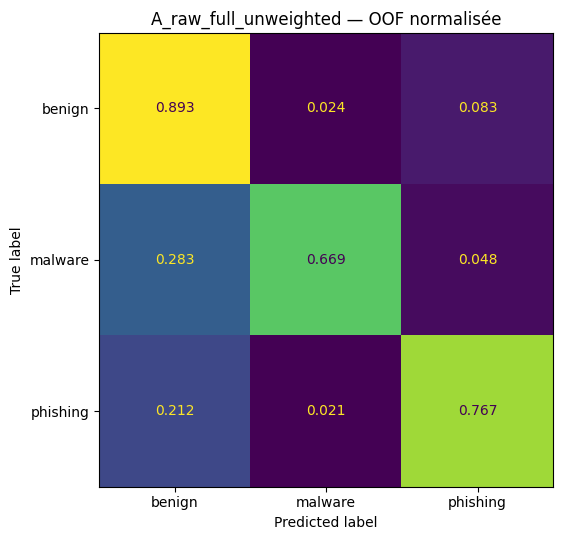

=== B_raw_full_balanced ===


,pred_benign,pred_malware,pred_phishing
true_benign,0.870748,0.038477,0.090774
true_malware,0.229039,0.728437,0.042524
true_phishing,0.197654,0.033145,0.769201


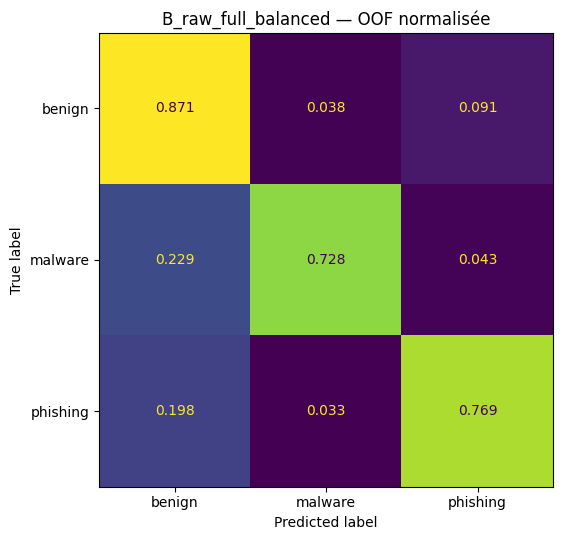

=== C_log1p_full_unweighted ===


,pred_benign,pred_malware,pred_phishing
true_benign,0.879783,0.027790,0.092427
true_malware,0.248743,0.717130,0.034127
true_phishing,0.192271,0.021668,0.786061


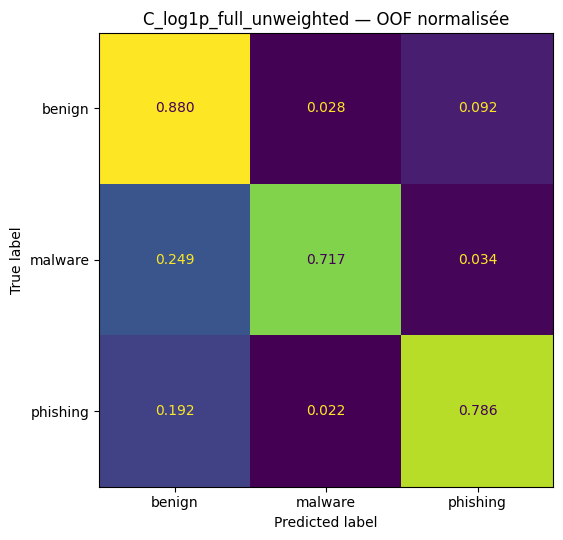

=== D_log1p_full_balanced ===


,pred_benign,pred_malware,pred_phishing
true_benign,0.854611,0.044379,0.101011
true_malware,0.159371,0.807540,0.033088
true_phishing,0.181415,0.034296,0.784290


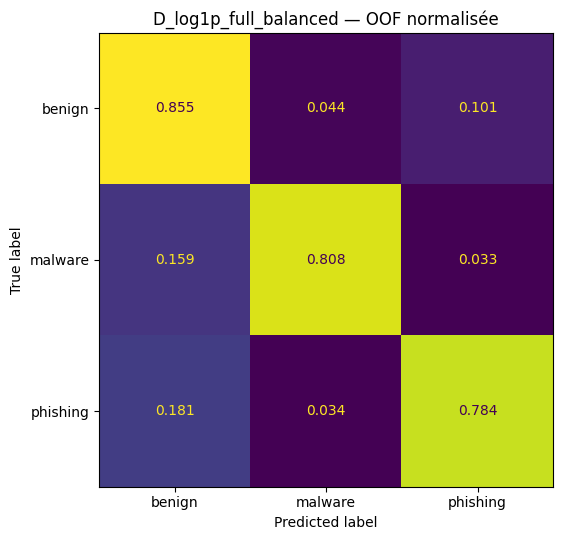

In [26]:
for config_name in (
    ABLATION_CONFIGS
):
    matrix = (
        oof_confusions[
            config_name
        ]
    )

    matrix_df = pd.DataFrame(
        matrix,
        index=[
            f"true_{label}"
            for label
            in LABEL_ORDER
        ],
        columns=[
            f"pred_{label}"
            for label
            in LABEL_ORDER
        ],
    )

    print(
        f"=== {config_name} ==="
    )
    display(
        matrix_df
        .round(
            6
        )
    )

    fig, ax = plt.subplots(
        figsize=(
            6.5,
            5.5,
        )
    )

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=LABEL_ORDER,
    ).plot(
        ax=ax,
        colorbar=False,
        values_format=".3f",
    )

    ax.set_title(
        f"{config_name} — OOF normalisée"
    )

    plt.tight_layout()
    plt.show()

## 15. Visualiser la stabilité par fold

Ces graphes ne servent pas à choisir un fold.

Ils servent à voir si une configuration :

- gagne de manière cohérente sur les 5 folds ;
- ou dépend fortement d'un seul fold favorable.

Une amélioration robuste doit idéalement déplacer l'ensemble des folds dans la bonne direction.

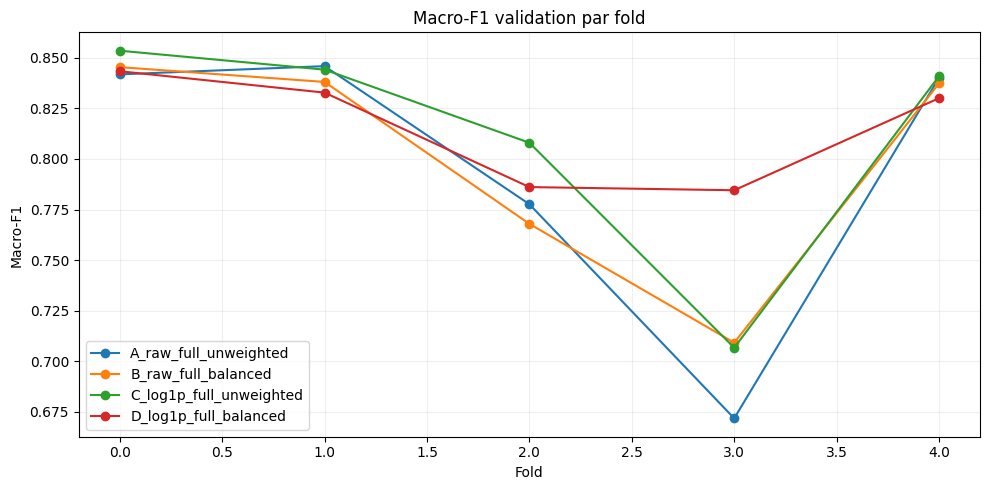

In [27]:
macro_plot_df = (
    fold_metrics_df[
        "f1_macro"
    ]
    .unstack(
        level="configuration"
    )
)

fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)

for column in (
    macro_plot_df.columns
):
    ax.plot(
        macro_plot_df.index,
        macro_plot_df[
            column
        ],
        marker="o",
        label=column,
    )

ax.set_title(
    "Macro-F1 validation par fold"
)
ax.set_xlabel(
    "Fold"
)
ax.set_ylabel(
    "Macro-F1"
)
ax.legend()
ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

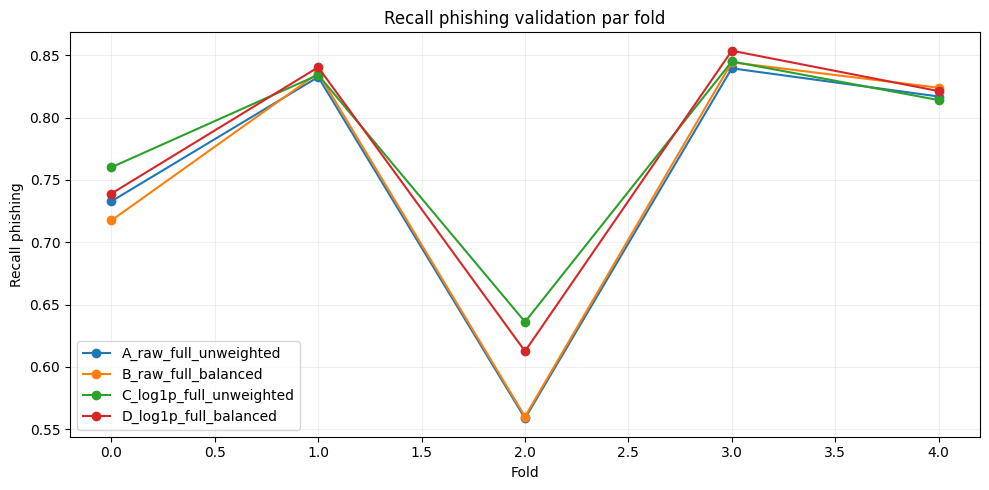

In [28]:
phishing_recall_plot_df = (
    phishing_fold_metrics[
        "recall"
    ]
    .unstack(
        level="configuration"
    )
)

fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)

for column in (
    phishing_recall_plot_df.columns
):
    ax.plot(
        phishing_recall_plot_df.index,
        phishing_recall_plot_df[
            column
        ],
        marker="o",
        label=column,
    )

ax.set_title(
    "Recall phishing validation par fold"
)
ax.set_xlabel(
    "Fold"
)
ax.set_ylabel(
    "Recall phishing"
)
ax.legend()
ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

## 16. Coût et convergence

La décision entre A/B/C/D ne doit pas sacrifier inutilement la simplicité opérationnelle.

Nous vérifions :

- temps de fit moyen ;
- nombre d'itérations ;
- warnings de convergence.

Avec 13 features seulement, les quatre variantes doivent rester adaptées à une plateforme légère.

In [29]:
runtime_summary = (
    runtime_df
    .groupby(
        level="configuration"
    )
    .agg(
        {
            "fit_seconds": [
                "mean",
                "std",
                "max",
            ],
            "solver_iterations_max": [
                "mean",
                "max",
            ],
            "convergence_warning_count": [
                "sum",
                "max",
            ],
        }
    )
)

display(
    runtime_summary
    .round(
        6
    )
)

fit_seconds                     solver_iterations_max      convergence_warning_count    
                               mean       std       max                  mean  max                       sum max
configuration                                                                                                   
A_raw_full_unweighted      2.530479  0.776405  3.539100                  64.6   73                         0   0
B_raw_full_balanced        2.104257  0.238777  2.324216                  61.0   65                         0   0
C_log1p_full_unweighted    2.966473  0.997431  4.595892                  92.4  118                         0   0
D_log1p_full_balanced      2.944498  0.411785  3.400008                  96.8  117                         0   0

# Partie VI — Aide à la décision

## 17. Classement descriptif des configurations

Le classement automatique suivant est **descriptif**.

La priorité reste :

1. macro-F1 moyen élevé ;
2. recall/F1 phishing élevé ;
3. faible dispersion entre folds ;
4. aucune dégradation excessive malware/benign ;
5. coût raisonnable.

Nous n'utilisons pas le test externe pour départager les configurations.

In [30]:
decision_rows = []

for config_name in (
    ABLATION_CONFIGS
):
    global_fold = (
        fold_metrics_df
        .loc[
            config_name
        ]
    )

    phishing_fold = (
        phishing_fold_metrics
        .loc[
            config_name
        ]
    )

    oof_phishing = (
        oof_class_df.loc[
            (
                config_name,
                "phishing",
            )
        ]
    )

    oof_benign = (
        oof_class_df.loc[
            (
                config_name,
                "benign",
            )
        ]
    )

    oof_malware = (
        oof_class_df.loc[
            (
                config_name,
                "malware",
            )
        ]
    )

    confusion = (
        oof_confusions[
            config_name
        ]
    )

    phishing_index = (
        LABEL_ORDER.index(
            "phishing"
        )
    )

    benign_index = (
        LABEL_ORDER.index(
            "benign"
        )
    )

    decision_rows.append(
        {
            "configuration": (
                config_name
            ),
            "cv_macro_f1_mean": float(
                global_fold[
                    "f1_macro"
                ].mean()
            ),
            "cv_macro_f1_std": float(
                global_fold[
                    "f1_macro"
                ].std(
                    ddof=1
                )
            ),
            "cv_balanced_accuracy_mean": float(
                global_fold[
                    "balanced_accuracy"
                ].mean()
            ),
            "cv_phishing_f1_mean": float(
                phishing_fold[
                    "f1"
                ].mean()
            ),
            "cv_phishing_recall_mean": float(
                phishing_fold[
                    "recall"
                ].mean()
            ),
            "oof_phishing_to_benign": float(
                confusion[
                    phishing_index,
                    benign_index,
                ]
            ),
            "oof_f1_benign": float(
                oof_benign[
                    "f1"
                ]
            ),
            "oof_f1_phishing": float(
                oof_phishing[
                    "f1"
                ]
            ),
            "oof_f1_malware": float(
                oof_malware[
                    "f1"
                ]
            ),
            "fit_seconds_mean": float(
                runtime_df
                .loc[
                    config_name,
                    "fit_seconds",
                ]
                .mean()
            ),
        }
    )


decision_table = (
    pd.DataFrame(
        decision_rows
    )
    .set_index(
        "configuration"
    )
    .sort_values(
        [
            "cv_macro_f1_mean",
            "cv_phishing_f1_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
)

display(
    decision_table
    .round(
        6
    )
)

,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_accuracy_mean,cv_phishing_f1_mean,cv_phishing_recall_mean,oof_phishing_to_benign,oof_f1_benign,oof_f1_phishing,oof_f1_malware,fit_seconds_mean
configuration,,,,,,,,,,
D_log1p_full_balanced,0.815393,0.027901,0.820783,0.808544,0.773343,0.181415,0.811542,0.820873,0.825925,2.944498
C_log1p_full_unweighted,0.810678,0.060645,0.812357,0.815383,0.777880,0.192271,0.804344,0.825688,0.792358,2.966473
B_raw_full_balanced,0.799595,0.059586,0.804937,0.799509,0.756316,0.197654,0.801280,0.813957,0.782060,2.104257
A_raw_full_unweighted,0.795455,0.074712,0.796998,0.799927,0.756079,0.211547,0.798542,0.814939,0.762914,2.530479


## 18. Résumé automatique des effets

Cette cellule ne décide pas du prochain modèle à notre place.

Elle extrait seulement :

- meilleure configuration CV observée ;
- gain moyen du weighting ;
- gain moyen de `log1p` ;
- gain combiné ;
- effet sur le recall phishing.

Après exécution, ces valeurs devront être interprétées avant de choisir entre :

- optimisation supplémentaire de Logistic Regression ;
- modèle non linéaire léger ;
- autre famille de modèle.

In [31]:
best_configuration = str(
    decision_table.index[
        0
    ]
)

summary = pd.Series(
    {
        "best_configuration_by_cv_macro_f1": (
            best_configuration
        ),
        "best_cv_macro_f1_mean": float(
            decision_table.loc[
                best_configuration,
                "cv_macro_f1_mean",
            ]
        ),
        "best_cv_macro_f1_std": float(
            decision_table.loc[
                best_configuration,
                "cv_macro_f1_std",
            ]
        ),
        "best_cv_phishing_f1_mean": float(
            decision_table.loc[
                best_configuration,
                "cv_phishing_f1_mean",
            ]
        ),
        "best_cv_phishing_recall_mean": float(
            decision_table.loc[
                best_configuration,
                "cv_phishing_recall_mean",
            ]
        ),
        "mean_delta_weight_raw_macro_f1": float(
            ablation_deltas_df
            .loc[
                "B_minus_A_weight_raw",
                "delta_macro_f1",
            ]
            .mean()
        ),
        "mean_delta_log1p_unweighted_macro_f1": float(
            ablation_deltas_df
            .loc[
                "C_minus_A_log1p_unweighted",
                "delta_macro_f1",
            ]
            .mean()
        ),
        "mean_delta_log1p_with_weight_macro_f1": float(
            ablation_deltas_df
            .loc[
                "D_minus_B_log1p_with_weight",
                "delta_macro_f1",
            ]
            .mean()
        ),
        "mean_delta_weight_with_log1p_macro_f1": float(
            ablation_deltas_df
            .loc[
                "D_minus_C_weight_with_log1p",
                "delta_macro_f1",
            ]
            .mean()
        ),
        "mean_delta_combined_macro_f1": float(
            ablation_deltas_df
            .loc[
                "D_minus_A_combined",
                "delta_macro_f1",
            ]
            .mean()
        ),
        "mean_delta_weight_raw_phishing_recall": float(
            ablation_deltas_df
            .loc[
                "B_minus_A_weight_raw",
                "delta_phishing_recall",
            ]
            .mean()
        ),
        "mean_delta_log1p_unweighted_phishing_recall": float(
            ablation_deltas_df
            .loc[
                "C_minus_A_log1p_unweighted",
                "delta_phishing_recall",
            ]
            .mean()
        ),
        "mean_delta_combined_phishing_recall": float(
            ablation_deltas_df
            .loc[
                "D_minus_A_combined",
                "delta_phishing_recall",
            ]
            .mean()
        ),
    },
    name="value",
)

display(
    summary.to_frame()
)

,value
best_configuration_by_cv_macro_f1,D_log1p_full_balanced
best_cv_macro_f1_mean,0.815393
best_cv_macro_f1_std,0.027901
best_cv_phishing_f1_mean,0.808544
best_cv_phishing_recall_mean,0.773343
mean_delta_weight_raw_macro_f1,0.004139
mean_delta_log1p_unweighted_macro_f1,0.015223
mean_delta_log1p_with_weight_macro_f1,0.015798
mean_delta_weight_with_log1p_macro_f1,0.004715
mean_delta_combined_macro_f1,0.019938


## Sauvegarde de la référence Logistic Regression V2

L'ablation a confirmé la configuration D comme meilleure référence linéaire globale :

- 13 features ;
- remplacement de 5 features par leur version `log1p` ;
- utilisation du train complet ;
- `StandardScaler` ;
- `LogisticRegression(class_weight="balanced")` ;
- `C=1.0` ;
- solver `lbfgs` ;
- seed expérimental `42`.

Les modèles produits pendant la cross-validation ne sont **pas** sauvegardés comme modèle final, car chacun n'a été entraîné que sur une partie du train.

Nous réentraînons donc la configuration D sur l'intégralité de `external_train_df`.

Le test externe 80/20 reste verrouillé et n'est pas utilisé lors de cet entraînement.

Cette Logistic Regression devient notre référence :

`LR-V2`

Elle servira de benchmark lors de la comparaison avec les prochaines familles de modèles.

### Important

Les performances de LR-V2 à utiliser pour comparer les familles pendant la phase de sélection restent les métriques de cross-validation / OOF :

- macro-F1 CV ≈ `0.8154 ± 0.0279` ;
- macro-F1 OOF ≈ `0.8194`.

Le modèle sauvegardé ci-dessous est un artefact entraîné sur tout le train externe ; il ne doit pas être utilisé pour recalculer des métriques sur les folds qui ont servi à sa sélection.

In [32]:
LR_V2_FEATURE_COLUMNS = list(
    LOG_FEATURE_COLUMNS
)

X_lr_v2_train = (
    external_train_df[
        LR_V2_FEATURE_COLUMNS
    ]
    .astype(float)
)

y_lr_v2_train = (
    external_train_df[
        "label_code"
    ]
)


# Garde-fous avant fit final.
if X_lr_v2_train.isna().any().any():
    raise RuntimeError(
        "NaN détecté dans le train LR-V2."
    )

if not np.isfinite(
    X_lr_v2_train.to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "Valeur non finie détectée "
        "dans le train LR-V2."
    )


lr_v2_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                C=1.0,
                max_iter=1_000,
                class_weight="balanced",
            ),
        ),
    ]
)


fit_started_at = (
    time.perf_counter()
)

with warnings.catch_warnings(
    record=True
) as caught_warnings:
    warnings.simplefilter(
        "always",
        ConvergenceWarning,
    )

    lr_v2_model.fit(
        X_lr_v2_train,
        y_lr_v2_train,
    )


fit_seconds = (
    time.perf_counter()
    - fit_started_at
)

convergence_warning_count = sum(
    1
    for warning
    in caught_warnings
    if issubclass(
        warning.category,
        ConvergenceWarning,
    )
)

classifier = (
    lr_v2_model
    .named_steps[
        "classifier"
    ]
)


print(
    "LR-V2 entraînée sur le train externe complet."
)

print(
    "Train rows:",
    len(
        X_lr_v2_train
    ),
)

print(
    "Features:",
    len(
        LR_V2_FEATURE_COLUMNS
    ),
)

print(
    "Fit seconds:",
    round(
        fit_seconds,
        4,
    ),
)

print(
    "Solver iterations:",
    int(
        np.max(
            classifier.n_iter_
        )
    ),
)

print(
    "Convergence warnings:",
    convergence_warning_count,
)


if convergence_warning_count != 0:
    raise RuntimeError(
        "LR-V2 n'a pas convergé proprement."
    )

LR-V2 entraînée sur le train externe complet.
Train rows: 114131
Features: 13
Fit seconds: 7.0823
Solver iterations: 90
Convergence warnings: 0


In [33]:
LR_V2_FEATURE_COLUMNS = list(
    LOG_FEATURE_COLUMNS
)

X_lr_v2_train = (
    external_train_df[
        LR_V2_FEATURE_COLUMNS
    ]
    .astype(float)
)

y_lr_v2_train = (
    external_train_df[
        "label_code"
    ]
)


# Garde-fous avant fit final.
if X_lr_v2_train.isna().any().any():
    raise RuntimeError(
        "NaN détecté dans le train LR-V2."
    )

if not np.isfinite(
    X_lr_v2_train.to_numpy(
        dtype=float
    )
).all():
    raise RuntimeError(
        "Valeur non finie détectée "
        "dans le train LR-V2."
    )


lr_v2_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                C=1.0,
                max_iter=1_000,
                class_weight="balanced",
            ),
        ),
    ]
)


fit_started_at = (
    time.perf_counter()
)

with warnings.catch_warnings(
    record=True
) as caught_warnings:
    warnings.simplefilter(
        "always",
        ConvergenceWarning,
    )

    lr_v2_model.fit(
        X_lr_v2_train,
        y_lr_v2_train,
    )


fit_seconds = (
    time.perf_counter()
    - fit_started_at
)

convergence_warning_count = sum(
    1
    for warning
    in caught_warnings
    if issubclass(
        warning.category,
        ConvergenceWarning,
    )
)

classifier = (
    lr_v2_model
    .named_steps[
        "classifier"
    ]
)


print(
    "LR-V2 entraînée sur le train externe complet."
)

print(
    "Train rows:",
    len(
        X_lr_v2_train
    ),
)

print(
    "Features:",
    len(
        LR_V2_FEATURE_COLUMNS
    ),
)

print(
    "Fit seconds:",
    round(
        fit_seconds,
        4,
    ),
)

print(
    "Solver iterations:",
    int(
        np.max(
            classifier.n_iter_
        )
    ),
)

print(
    "Convergence warnings:",
    convergence_warning_count,
)


if convergence_warning_count != 0:
    raise RuntimeError(
        "LR-V2 n'a pas convergé proprement."
    )

LR-V2 entraînée sur le train externe complet.
Train rows: 114131
Features: 13
Fit seconds: 7.2007
Solver iterations: 90
Convergence warnings: 0


In [34]:
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib


MODEL_NAME = (
    "url_multiclass_logistic_regression_v2"
)

MODEL_VERSION = (
    "lr-v2"
)

MODEL_ARTIFACT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "ml"
    / "models"
)

MODEL_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


model_path = (
    MODEL_ARTIFACT_DIR
    / f"{MODEL_NAME}.joblib"
)

metadata_path = (
    MODEL_ARTIFACT_DIR
    / f"{MODEL_NAME}.metadata.json"
)


artifact = {
    "artifact_version": (
        MODEL_VERSION
    ),

    "model": (
        lr_v2_model
    ),

    # Ordre exact attendu par le modèle.
    "feature_columns": list(
        LR_V2_FEATURE_COLUMNS
    ),

    # Permet de reconstruire la représentation.
    "source_feature_columns": list(
        RAW_FEATURE_COLUMNS
    ),

    "log1p_features": list(
        LOG1P_FEATURES
    ),

    "log1p_column_map": dict(
        LOG1P_COLUMN_MAP
    ),

    "label_order": list(
        LABEL_ORDER
    ),

    "probability_label_order": list(
        PROBABILITY_LABEL_ORDER
    ),
}


joblib.dump(
    artifact,
    model_path,
    compress=3,
)


def sha256_file(
    path: Path,
) -> str:
    digest = hashlib.sha256()

    with path.open(
        "rb"
    ) as handle:
        for chunk in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(
                chunk
            )

    return digest.hexdigest()


model_sha256 = sha256_file(
    model_path
)


metadata = {
    "model_name": (
        MODEL_NAME
    ),

    "model_version": (
        MODEL_VERSION
    ),

    "created_at_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),

    "model_family": (
        "LogisticRegression"
    ),

    "configuration": (
        "D_log1p_full_balanced"
    ),

    "feature_set_version": (
        EXPECTED_FEATURE_SET_VERSION
    ),

    "feature_count": (
        len(
            LR_V2_FEATURE_COLUMNS
        )
    ),

    "feature_columns": list(
        LR_V2_FEATURE_COLUMNS
    ),

    "log1p_features": list(
        LOG1P_FEATURES
    ),

    "class_weight": (
        "balanced"
    ),

    "scaler": (
        "StandardScaler"
    ),

    "solver": (
        "lbfgs"
    ),

    "C": 1.0,

    "max_iter": 1_000,

    "random_seed": (
        RANDOM_SEED
    ),

    "training_rows": int(
        len(
            external_train_df
        )
    ),

    "training_strategy": (
        "full external train"
    ),

    "external_test_used_for_fit": False,

    "selection_protocol": (
        "5-fold StratifiedGroupKFold "
        "on external train"
    ),

    "cv_reference": {
        "macro_f1_mean": (
            0.8154
        ),
        "macro_f1_std": (
            0.0279
        ),
        "oof_macro_f1": (
            0.8194
        ),
        "oof_phishing_to_benign": (
            0.1814
        ),
    },

    "model_sha256": (
        model_sha256
    ),
}


with metadata_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        metadata,
        handle,
        ensure_ascii=False,
        indent=2,
    )


print(
    "LR-V2 sauvegardée."
)

print(
    "Model:",
    model_path.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "Metadata:",
    metadata_path.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "SHA-256:",
    model_sha256,
)

LR-V2 sauvegardée.
Model: artifacts\ml\models\url_multiclass_logistic_regression_v2.joblib
Metadata: artifacts\ml\models\url_multiclass_logistic_regression_v2.metadata.json
SHA-256: a476e5be571f5ec8d85181d267fc86a9d309319804b4dc9a9967b272587794be


# Conclusion — Ablation Logistic Regression et décision pour la prochaine phase

## 1. Objectif de l'expérience

Cette expérience avait pour objectif d'identifier précisément l'origine du gain observé entre la baseline Logistic Regression V1 et la Candidate V2.

La Candidate V2 avait introduit simultanément plusieurs changements :

1. utilisation de l'ensemble complet du train au lieu d'un sous-échantillonnage ;
2. ajout de `class_weight="balanced"` ;
3. remplacement de cinq features fortement asymétriques par leur version `log1p`.

Il était donc impossible, à partir de cette seule expérience, de déterminer quelle modification expliquait réellement l'amélioration.

L'ablation a comparé quatre configurations sur **exactement les mêmes folds internes stratifiés et group-aware** :

| Configuration | Features | Train | Class weighting |
|---|---|---|---|
| A | brutes | complet | aucun |
| B | brutes | complet | `balanced` |
| C | `log1p` | complet | aucun |
| D | `log1p` | complet | `balanced` |

Le test externe historique 80/20 a volontairement été conservé hors de la sélection.

Toutes les conclusions de cette section proviennent donc uniquement de la cross-validation interne.

---

# 2. Résultat global de l'ablation

Les performances moyennes en cross-validation sont :

| Configuration | Macro-F1 moyen | Écart-type | Balanced Accuracy |
|---|---:|---:|---:|
| A — raw / unweighted | 0.7955 | 0.0747 | 0.7970 |
| B — raw / balanced | 0.7996 | 0.0596 | 0.8049 |
| C — log1p / unweighted | 0.8107 | 0.0606 | 0.8124 |
| **D — log1p / balanced** | **0.8154** | **0.0279** | **0.8208** |

La configuration D obtient donc :

- le meilleur macro-F1 moyen ;
- la meilleure balanced accuracy ;
- la plus faible dispersion entre folds.

Le résultat le plus important n'est pas seulement le score moyen.

La configuration D est aussi **beaucoup plus stable** que les autres.

Son écart-type de macro-F1 est :

`0.0279`

contre :

- A : `0.0747` ;
- B : `0.0596` ;
- C : `0.0606`.

Cette réduction de variance indique que la combinaison `log1p + class_weight="balanced"` résiste mieux aux changements de composition entre groupes/domaines.

---

# 3. Effet isolé de `log1p`

Pour isoler l'effet de `log1p`, nous comparons :

`C - A`

Les deux configurations utilisent :

- le même modèle ;
- le même train complet ;
- aucune pondération de classe.

La seule différence est donc la représentation des cinq features transformées.

Les deltas moyens sont approximativement :

- macro-F1 : **+0.0152** ;
- balanced accuracy : **+0.0154** ;
- F1 phishing : **+0.0155** ;
- recall phishing : **+0.0218**.

Le gain apparaît sur la majorité des folds.

Nous pouvons donc conclure que :

> **les transformations `log1p` améliorent réellement la capacité de Logistic Regression à exploiter les features.**

Leur intérêt n'est donc pas seulement descriptif.

La réduction de skewness observée dans l'EDA améliore effectivement la géométrie du problème pour un modèle linéaire.

### Décision

Les cinq transformations suivantes sont conservées pour notre Logistic Regression de référence :

- `log1p_url_length` ;
- `log1p_dot_count` ;
- `log1p_digit_count` ;
- `log1p_special_char_count` ;
- `log1p_path_segment_count`.

---

# 4. Effet isolé de `class_weight="balanced"`

Pour isoler l'effet du weighting sur les features brutes, nous comparons :

`B - A`

Les deltas moyens sont beaucoup plus faibles :

- macro-F1 : environ **+0.0041** ;
- balanced accuracy : environ **+0.0079** ;
- F1 phishing : environ `-0.0004` ;
- recall phishing : environ `+0.0002`.

Cela montre que :

> **le class weighting n'explique pas à lui seul le gain important observé précédemment sur phishing.**

Sur les features brutes, son effet sur phishing est pratiquement neutre.

Le principal facteur d'amélioration phishing est donc davantage lié à la représentation des features qu'à leur pondération.

---

# 5. Pourquoi conserver malgré tout le class weighting ?

Même s'il apporte peu de gain moyen sur phishing, `class_weight="balanced"` possède deux bénéfices importants.

## 5.1. Recall malware

Sur les prédictions OOF :

### C — log1p sans weighting

- precision malware : environ `0.885` ;
- recall malware : environ `0.717` ;
- F1 malware : environ `0.792`.

### D — log1p + weighting

- precision malware : environ `0.845` ;
- recall malware : environ **`0.808`** ;
- F1 malware : environ **`0.826`**.

Le weighting augmente donc fortement la récupération des malware.

Cette amélioration est obtenue au prix d'une petite baisse de precision, mais le compromis est favorable pour une plateforme de Threat Intelligence.

---

## 5.2. Robustesse entre folds

Le deuxième effet important est la stabilité.

La configuration D conserve de bonnes performances même lorsque la distribution des groupes devient plus difficile.

C'est particulièrement visible sur le fold où la proportion malware est nettement plus élevée que dans les autres validations.

Dans ce contexte, `class_weight="balanced"` réduit fortement la dégradation de performance.

Cela explique pourquoi :

`std macro-F1 D = 0.0279`

est nettement inférieur à celui de C :

`std macro-F1 C = 0.0606`.

Le weighting agit donc davantage comme un mécanisme de **robustesse inter-groupes** que comme un mécanisme spécifique d'amélioration phishing.

---

# 6. Performance phishing

Le phishing reste la classe métier prioritaire.

Les moyennes CV montrent approximativement :

### C — log1p sans weighting

- F1 phishing : `0.8154` ;
- recall phishing : `0.7779`.

### D — log1p + weighting

- F1 phishing : `0.8085` ;
- recall phishing : `0.7733`.

C obtient donc une performance phishing légèrement supérieure en moyenne.

Cependant, la différence est faible et D possède de meilleurs résultats globaux et une meilleure robustesse.

---

# 7. Analyse de `phishing → benign`

L'erreur la plus critique depuis la baseline reste :

`phishing → benign`

Les prédictions OOF montrent :

| Configuration | Phishing classé benign |
|---|---:|
| A | 21.15 % |
| B | 19.77 % |
| C | 19.23 % |
| **D** | **18.14 %** |

La configuration D réduit donc le plus fortement la fuite de phishing vers la classe benign.

C'est particulièrement important dans un contexte Threat Intelligence.

Une erreur :

`phishing → malware`

reste une erreur multiclasses,

mais elle est opérationnellement moins dangereuse qu'une erreur :

`phishing → benign`.

Avec D, une partie des erreurs phishing est justement déplacée de benign vers malware.

Cela explique pourquoi son F1 phishing n'est pas maximal alors que son comportement de sécurité est meilleur.

---

# 8. Prédictions OOF

Les macro-F1 OOF obtenus sont :

| Configuration | Macro-F1 OOF |
|---|---:|
| A | 0.7921 |
| B | 0.7991 |
| C | 0.8075 |
| **D** | **0.8194** |

La progression :

`A → B → C → D`

confirme les résultats moyens des folds.

Pour la configuration D, les F1 OOF sont approximativement :

- benign : **0.8115** ;
- phishing : **0.8209** ;
- malware : **0.8259**.

Les performances deviennent donc beaucoup plus équilibrées entre les trois classes.

C'est un résultat particulièrement intéressant puisque notre baseline initiale était beaucoup plus hétérogène entre classes.

---

# 9. Qualité des probabilités

La configuration D n'améliore pas seulement le label final.

Comparée à A, elle améliore également plusieurs métriques probabilistes :

| Métrique | A | D |
|---|---:|---:|
| ROC-AUC macro | ~0.906 | **~0.933** |
| Average Precision macro | ~0.845 | **~0.887** |
| Log-loss | ~0.590 | **~0.488** |
| Top-2 accuracy | ~0.937 | **~0.966** |
| Brier multiclasses | ~0.301 | **~0.269** |

Cela indique que le classement probabiliste des classes est également meilleur.

Cette propriété sera utile si la plateforme expose plus tard :

- un label prédit ;
- un score ;
- une confiance ou un niveau de risque.

Cependant, les probabilités ne doivent pas encore être considérées comme parfaitement calibrées.

Une étude spécifique de calibration sera nécessaire avant de leur donner une interprétation opérationnelle directe.

---

# 10. Coût computationnel

Les quatre configurations restent extrêmement légères.

Temps moyen de fit par fold :

- A : environ `2.53 s` ;
- B : environ `2.10 s` ;
- C : environ `2.97 s` ;
- D : environ `2.94 s`.

Warnings de convergence :

`0`

pour toutes les configurations.

La Candidate D ne crée donc aucune complexité opérationnelle significative.

Avec seulement 13 features, son coût reste parfaitement compatible avec une architecture scalable.

---

# 11. Ce que l'ablation permet maintenant d'affirmer

## `log1p`

Effet :

**positif, régulier et mesurable.**

Il améliore :

- macro-F1 ;
- balanced accuracy ;
- phishing ;
- qualité des probabilités.

### Décision

**Conserver.**

---

## `class_weight="balanced"`

Effet moyen :

plus faible que `log1p`.

Mais il améliore :

- recall malware ;
- balanced accuracy ;
- robustesse aux folds difficiles ;
- réduction de `phishing → benign`.

### Décision

**Conserver dans le candidat global.**

---

## Combinaison D

La combinaison :

`log1p + full train + class_weight="balanced"`

obtient :

- meilleur macro-F1 moyen ;
- meilleure balanced accuracy ;
- meilleur macro-F1 OOF ;
- meilleure stabilité ;
- meilleur compromis inter-classes ;
- taux `phishing → benign` le plus faible.

### Décision

La configuration D devient notre :

# **Logistic Regression Candidate V2**

---

# 12. Référence Logistic Regression actuelle

La référence linéaire devient :

| Élément | Valeur |
|---|---|
| Modèle | Logistic Regression |
| Features | 13 |
| Transformations | 5 `log1p` |
| Scaling | `StandardScaler` |
| Train | complet |
| Class weighting | `balanced` |
| CV | Stratified + Group-aware, 5 folds |
| Macro-F1 CV | **0.8154 ± 0.0279** |
| Balanced Accuracy CV | **0.8208** |
| F1 phishing CV | **~0.8085** |
| Recall phishing CV | **~0.7733** |
| Macro-F1 OOF | **0.8194** |
| F1 benign OOF | **0.8115** |
| F1 phishing OOF | **0.8209** |
| F1 malware OOF | **0.8259** |
| Phishing → benign | **18.14 %** |

Cette configuration constitue maintenant notre **référence linéaire** pour comparer les prochaines familles de modèles.

---

# 13. Limite restante : effet propre du full train

Une dimension n'a pas encore été isolée complètement.

Les quatre configurations A/B/C/D utilisent toutes le train complet.

L'ablation permet donc d'isoler :

- `log1p` ;
- `class_weight`.

Mais elle ne compare pas directement :

`ancien downsampling group-aware`

contre :

`full train`.

Nous savons que la baseline utilisait environ :

`72 171 observations`

alors que le train 80/20 complet en contient :

`114 131`.

Il est très probable que cette récupération d'environ `42 000` exemples supplémentaires contribue au gain, mais l'expérience actuelle ne permet pas de quantifier précisément cet effet.

---

# 14. Dernière micro-ablation proposée

Avant de clôturer complètement la phase Logistic Regression, une dernière configuration peut être ajoutée :

## Configuration E

`features brutes + downsampling group-aware + aucun class_weight`

sur exactement les mêmes folds internes.

La comparaison :

`E vs A`

permettra d'isoler directement :

> l'effet du passage du train sous-échantillonné vers le train complet.

Cette expérience doit rester courte.

Il n'est pas nécessaire de relancer une grande campagne de tuning Logistic Regression.

---

# 15. Pourquoi passer ensuite à une autre famille de modèles ?

La Logistic Regression est maintenant correctement optimisée méthodologiquement :

- features nettoyées ;
- transformations validées ;
- full train ;
- class weighting ;
- split group-aware ;
- cross-validation group-aware ;
- métriques OOF ;
- analyse par classe ;
- analyse probabiliste.

Pourtant, il reste environ :

`18.14 %`

des phishing OOF classés benign.

Cette erreur suggère que certaines frontières entre benign et phishing pourraient dépendre :

- d'interactions entre features ;
- de seuils non linéaires ;
- de régions locales de l'espace de features.

Une Logistic Regression ne peut représenter ces structures qu'avec une frontière linéaire dans l'espace transformé.

La prochaine question devient donc :

> **un modèle non linéaire peut-il dépasser significativement la Logistic Regression sans perdre sa robustesse et sa simplicité opérationnelle ?**

---

# 16. Prochaine étape — comparaison entre familles de modèles

Le prochain notebook devra utiliser :

- exactement le même train externe ;
- exactement les mêmes folds internes ;
- exactement les mêmes 13 features validées ;
- exactement les mêmes métriques.

L'objectif sera de changer uniquement la **famille de modèle**.

## Modèle 1 — Logistic Regression V2

Référence :

`log1p + StandardScaler + class_weight="balanced"`

Elle constitue le benchmark linéaire.

---

## Modèle 2 — HistGradientBoostingClassifier

Premier modèle non linéaire recommandé.

Raisons :

- adapté aux données tabulaires ;
- apprend naturellement des interactions ;
- apprend des seuils non linéaires ;
- performant sur un volume de l'ordre de 100k observations ;
- faible coût avec seulement 13 features ;
- disponible directement dans scikit-learn ;
- pas de nouvelle dépendance externe.

Il permettra de tester directement l'hypothèse :

> la limite actuelle vient-elle principalement de la linéarité du modèle ?

---

## Modèle 3 — ExtraTreesClassifier

Deuxième famille recommandée.

Son objectif est moins d'être forcément le modèle final que de fournir une référence arbre très différente :

- partitions non linéaires ;
- interactions automatiques ;
- forte randomisation ;
- peu de preprocessing.

La comparaison deviendra alors :

`Logistic Regression`

vs

`Histogram Gradient Boosting`

vs

`Extra Trees`

Cela fournit trois biais inductifs différents sans multiplier inutilement les modèles.

---

# 17. Ce que nous ne faisons pas encore

À ce stade, il n'est pas nécessaire d'introduire :

- réseaux de neurones ;
- SVM RBF sur tout le dataset ;
- XGBoost + LightGBM + CatBoost simultanément ;
- stacking ;
- ensembles complexes ;
- recherche exhaustive d'hyperparamètres.

Le projet doit rester simple, reproductible et performant.

Nous cherchons d'abord à comprendre **quel type de frontière de décision convient le mieux à nos 13 features**.

---

# 18. Méthodologie du prochain benchmark

Pour chaque modèle :

1. utiliser exactement les mêmes folds group-aware ;
2. entraîner uniquement sur le train du fold ;
3. prédire la validation ;
4. construire les prédictions OOF ;
5. mesurer :
   - macro-F1 ;
   - balanced accuracy ;
   - F1/recall phishing ;
   - `phishing → benign` ;
   - F1 malware ;
   - F1 benign ;
   - MCC ;
   - ROC-AUC ;
   - Average Precision ;
   - log-loss lorsque disponible ;
   - temps de fit ;
   - temps d'inférence ;
6. comparer moyenne et écart-type entre folds.

Aucun modèle ne devra être choisi uniquement sur son meilleur fold.

---

# 19. Critères de sélection du prochain modèle

Un modèle non linéaire sera considéré comme réellement meilleur uniquement s'il apporte un gain reproductible.

Nous chercherons idéalement :

- macro-F1 CV supérieur à `0.8154` ;
- F1 phishing supérieur à environ `0.8085` ;
- réduction de `phishing → benign` sous `18 %` ;
- stabilité au moins comparable à `std ≈ 0.028` ;
- aucune forte dégradation malware ;
- temps d'entraînement et d'inférence compatibles avec la plateforme.

Un gain très faible accompagné d'une forte hausse de complexité ne justifiera pas le changement de modèle.

---

# 20. Limites méthodologiques toujours présentes

Même avec une meilleure famille de modèle, plusieurs limites du dataset restent inchangées.

## Source-label confounding

Les classes restent fortement liées aux sources :

- HTTP Archive → benign ;
- PhishTank → phishing ;
- URLhaus → malware.

Un modèle peut donc exploiter indirectement certaines signatures propres aux sources.

Une performance élevée ne prouve pas encore une généralisation parfaite vers de nouvelles sources.

---

## Groupes multi-labels

`12 126` observations restent volontairement quarantainées.

Elles représentent probablement des cas plus difficiles :

- domaines compromis ;
- infrastructures partagées ;
- domaines contenant plusieurs comportements.

Elles devront devenir un stress test dédié après sélection du modèle principal.

---

## Robustesse temporelle

La cross-validation actuelle est group-aware mais pas temporelle.

Une fois le meilleur modèle sélectionné, une expérience séparée devra mesurer la généralisation vers les menaces les plus récentes.

---

# Conclusion générale

L'ablation confirme que la Logistic Regression possède encore une bonne capacité avec notre Feature Set compact.

Le principal gain provient des transformations `log1p`, tandis que `class_weight="balanced"` améliore surtout :

- l'équilibre entre classes ;
- le recall malware ;
- la robustesse aux folds difficiles ;
- la réduction de `phishing → benign`.

La configuration :

`13 features + log1p + StandardScaler + LogisticRegression(class_weight="balanced")`

est désormais notre **référence linéaire officielle**.

Elle atteint environ :

- macro-F1 CV : **`0.8154 ± 0.0279`** ;
- macro-F1 OOF : **`0.8194`** ;
- F1 phishing OOF : **`0.8209`** ;
- F1 malware OOF : **`0.8259`** ;
- `phishing → benign` : **`18.14 %`**.

La prochaine phase ne doit plus chercher à complexifier la Logistic Regression.

Après une éventuelle micro-ablation permettant d'isoler l'effet du full train, nous devons passer à une **comparaison contrôlée entre familles de modèles**, en commençant par :

1. Logistic Regression V2 ;
2. `HistGradientBoostingClassifier` ;
3. `ExtraTreesClassifier`.

Cette comparaison permettra de déterminer si la limite restante vient principalement de la **linéarité du modèle**, ou si elle provient davantage des **features et de la diversité des données**.